## Features Description

### Numerical Features
| Feature | Description |
|-------|-------------|
| **age** | Age of the individual |
| **fnlwgt** | Final sampling weight assigned by the Census Bureau |
| **education-num** | Numerical representation of education level |
| **capital-gain** | Capital gains income |
| **capital-loss** | Capital losses |
| **hours-per-week** | Number of working hours per week |

---

### Categorical Features
| Feature | Possible Values |
|-------|----------------|
| **workclass** | Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked |
| **education** | Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool |
| **marital-status** | Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse |
| **occupation** | Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces |
| **relationship** | Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried |
| **race** | White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black |
| **sex** | Female, Male |
| **native-country** | United-States, Cambodia, England, Puerto-Rico, Canada, Germany, India, Japan, Greece, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands |

---

### Target Variable
| Feature | Description |
|-------|-------------|
| **class** | Income category: **>50K** or **<=50K** |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import RobustScaler, StandardScaler

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score, confusion_matrix


import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"adult.csv")
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


# Feature Engineering

## education_grouped

In [ ]:
edu_map = {
    "Preschool": "Primary Education",
    "1st-4th": "Primary Education",
    "5th-6th": "Primary Education",

    "7th-8th": "Lower Secondary Education",
    "9th": "Lower Secondary Education",

    "10th": "Upper Secondary Education",
    "11th": "Upper Secondary Education",
    "12th": "Upper Secondary Education",
    "HS-grad": "Upper Secondary Education",

    "Some-college": "Post-Secondary / Associate",
    "Assoc-acdm": "Post-Secondary / Associate",
    "Assoc-voc": "Post-Secondary / Associate",

    "Bachelors": "Bachelor's Degree",

    "Masters": "Graduate / Professional",
    "Doctorate": "Graduate / Professional",
    "Prof-school": "Graduate / Professional"
}

df["education_grouped"] = df["education"].map(edu_map)

# Cleaning

## Check for Missing values

In [ ]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


## Check for Duplicated Values

In [ ]:
df.duplicated().sum()

np.int64(52)

In [ ]:
df[df.duplicated(keep=False)]

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,education_grouped
488,24,Private,194630,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K,Bachelor's Degree
864,24,Private,194630,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K,Bachelor's Degree
1319,37,Private,52870,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,<=50K,Bachelor's Degree
1668,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K,Primary Education
1854,22,Private,137876,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,20,United-States,<=50K,Post-Secondary / Associate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46665,20,?,203353,Some-college,10,Never-married,?,Own-child,White,Female,0,0,40,United-States,<=50K,Post-Secondary / Associate
46979,22,?,334593,Some-college,10,Never-married,?,Not-in-family,White,Male,0,0,40,United-States,<=50K,Post-Secondary / Associate
47126,46,Private,133616,Some-college,10,Divorced,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,Post-Secondary / Associate
48274,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K,Post-Secondary / Associate


In [ ]:
df = df.drop_duplicates(keep="last")

In [ ]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,education_grouped
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,Upper Secondary Education
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,Upper Secondary Education
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,Post-Secondary / Associate
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,Post-Secondary / Associate
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K,Post-Secondary / Associate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,Post-Secondary / Associate
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,Upper Secondary Education
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,Upper Secondary Education
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K,Upper Secondary Education


In [ ]:
pd.set_option("display.max_rows",50)

In [ ]:
for i in df.columns:
    print(df[i].value_counts())
    print("-"*25)

age
36    1348
35    1336
33    1335
23    1325
31    1324
      ... 
88       6
85       5
87       3
89       2
86       1
Name: count, Length: 74, dtype: int64
-------------------------
workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
?                    2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64
-------------------------
fnlwgt
203488    21
190290    19
120277    19
125892    18
126569    18
          ..
403910     1
381895     1
217597     1
63079      1
177669     1
Name: count, Length: 28523, dtype: int64
-------------------------
education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5t

## workclass

In [ ]:
missing_work = df.loc[df.workclass == "?"]
missing_work

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,education_grouped
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K,Post-Secondary / Associate
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K,Upper Secondary Education
13,58,?,299831,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,0,35,United-States,<=50K,Upper Secondary Education
22,72,?,132015,7th-8th,4,Divorced,?,Not-in-family,White,Female,0,0,6,United-States,<=50K,Lower Secondary Education
35,65,?,191846,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,0,40,United-States,<=50K,Upper Secondary Education
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K,Bachelor's Degree
48812,30,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K,Bachelor's Degree
48820,71,?,287372,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0,0,10,United-States,>50K,Graduate / Professional
48822,41,?,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K,Upper Secondary Education


In [ ]:
missing_work = missing_work.age.value_counts().reset_index()
missing_work = missing_work.sort_values(by="age" , ascending=True)
missing_work

,age,count
5,17,97
2,18,154
1,19,182
0,20,183
3,21,147
...,...,...
68,83,2
67,84,4
69,87,2
70,89,1


In [ ]:
df.loc[df.workclass == "?", "workclass"] = "Unknown"

## occupation

In [ ]:
df.loc[df.occupation == "?", "workclass"].value_counts()

,count
workclass,
Unknown,2795
Never-worked,10


In [ ]:
df.loc[df.workclass == "Unknown"]

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,education_grouped
4,18,Unknown,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K,Post-Secondary / Associate
6,29,Unknown,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K,Upper Secondary Education
13,58,Unknown,299831,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,0,35,United-States,<=50K,Upper Secondary Education
22,72,Unknown,132015,7th-8th,4,Divorced,?,Not-in-family,White,Female,0,0,6,United-States,<=50K,Lower Secondary Education
35,65,Unknown,191846,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,0,40,United-States,<=50K,Upper Secondary Education
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,Unknown,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K,Bachelor's Degree
48812,30,Unknown,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K,Bachelor's Degree
48820,71,Unknown,287372,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0,0,10,United-States,>50K,Graduate / Professional
48822,41,Unknown,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K,Upper Secondary Education


In [ ]:
df.loc[df.workclass == "Never-worked"]

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,education_grouped
8785,17,Never-worked,131593,11th,7,Never-married,?,Own-child,Black,Female,0,0,20,United-States,<=50K,Upper Secondary Education
11607,20,Never-worked,273905,HS-grad,9,Married-spouse-absent,?,Other-relative,White,Male,0,0,35,United-States,<=50K,Upper Secondary Education
13898,18,Never-worked,162908,11th,7,Never-married,?,Own-child,White,Male,0,0,35,United-States,<=50K,Upper Secondary Education
21642,18,Never-worked,206359,10th,6,Never-married,?,Own-child,White,Male,0,0,40,United-States,<=50K,Upper Secondary Education
27126,23,Never-worked,188535,7th-8th,4,Divorced,?,Not-in-family,White,Male,0,0,35,United-States,<=50K,Lower Secondary Education
31053,17,Never-worked,237272,10th,6,Never-married,?,Own-child,White,Male,0,0,30,United-States,<=50K,Upper Secondary Education
36618,18,Never-worked,157131,11th,7,Never-married,?,Own-child,White,Female,0,0,10,United-States,<=50K,Upper Secondary Education
39513,20,Never-worked,462294,Some-college,10,Never-married,?,Own-child,Black,Male,0,0,40,United-States,<=50K,Post-Secondary / Associate
48585,30,Never-worked,176673,HS-grad,9,Married-civ-spouse,?,Wife,Black,Female,0,0,40,United-States,<=50K,Upper Secondary Education
48595,18,Never-worked,153663,Some-college,10,Never-married,?,Own-child,White,Male,0,0,4,United-States,<=50K,Post-Secondary / Associate


In [ ]:
df.loc[df.workclass == "Unknown", "occupation"] = "Unknown"

In [ ]:
df.loc[df.workclass == "Never-worked", "occupation"] = "Unemployed"

## education & educational-num

In [ ]:
for i in df.education.unique():
    print(f"{i} -> {df.loc[df.education == i, "educational-num"].value_counts()}")
    print("-"*20)

11th -> educational-num
7    1812
Name: count, dtype: int64
--------------------
HS-grad -> educational-num
9    15770
Name: count, dtype: int64
--------------------
Assoc-acdm -> educational-num
12    1601
Name: count, dtype: int64
--------------------
Some-college -> educational-num
10    10863
Name: count, dtype: int64
--------------------
10th -> educational-num
6    1389
Name: count, dtype: int64
--------------------
Prof-school -> educational-num
15    834
Name: count, dtype: int64
--------------------
7th-8th -> educational-num
4    954
Name: count, dtype: int64
--------------------
Bachelors -> educational-num
13    8013
Name: count, dtype: int64
--------------------
Masters -> educational-num
14    2656
Name: count, dtype: int64
--------------------
Doctorate -> educational-num
16    594
Name: count, dtype: int64
--------------------
5th-6th -> educational-num
3    507
Name: count, dtype: int64
--------------------
Assoc-voc -> educational-num
11    2060
Name: count, dtype: in

## native-country

In [ ]:
df[df["native-country"] == "?"]

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,education_grouped
19,40,Private,85019,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,45,?,>50K,Graduate / Professional
65,41,Private,109912,Bachelors,13,Never-married,Other-service,Not-in-family,White,Female,0,0,40,?,<=50K,Bachelor's Degree
83,44,Self-emp-inc,223881,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,99999,0,50,?,>50K,Upper Secondary Education
188,34,State-gov,513100,Bachelors,13,Married-spouse-absent,Farming-fishing,Not-in-family,Black,Male,0,0,40,?,<=50K,Bachelor's Degree
253,42,Federal-gov,177937,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,40,?,<=50K,Bachelor's Degree
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48730,44,Self-emp-inc,71556,Masters,14,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,?,>50K,Graduate / Professional
48750,58,Self-emp-inc,181974,Doctorate,16,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,99,?,<=50K,Graduate / Professional
48773,42,Self-emp-not-inc,217597,HS-grad,9,Divorced,Sales,Own-child,White,Male,0,0,50,?,<=50K,Upper Secondary Education
48791,39,Private,107302,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,45,?,>50K,Upper Secondary Education


In [ ]:
for i in df.columns:
    print(df[i].value_counts())
    print("-"*25)

age
36    1348
35    1336
33    1335
23    1325
31    1324
      ... 
88       6
85       5
87       3
89       2
86       1
Name: count, Length: 74, dtype: int64
-------------------------
workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
Unknown              2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64
-------------------------
fnlwgt
203488    21
190290    19
120277    19
125892    18
126569    18
          ..
403910     1
381895     1
217597     1
63079      1
177669     1
Name: count, Length: 28523, dtype: int64
-------------------------
education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5t

In [ ]:
df.loc[df["native-country"] == "?"]

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,education_grouped
19,40,Private,85019,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,45,?,>50K,Graduate / Professional
65,41,Private,109912,Bachelors,13,Never-married,Other-service,Not-in-family,White,Female,0,0,40,?,<=50K,Bachelor's Degree
83,44,Self-emp-inc,223881,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,99999,0,50,?,>50K,Upper Secondary Education
188,34,State-gov,513100,Bachelors,13,Married-spouse-absent,Farming-fishing,Not-in-family,Black,Male,0,0,40,?,<=50K,Bachelor's Degree
253,42,Federal-gov,177937,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,40,?,<=50K,Bachelor's Degree
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48730,44,Self-emp-inc,71556,Masters,14,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,?,>50K,Graduate / Professional
48750,58,Self-emp-inc,181974,Doctorate,16,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,99,?,<=50K,Graduate / Professional
48773,42,Self-emp-not-inc,217597,HS-grad,9,Divorced,Sales,Own-child,White,Male,0,0,50,?,<=50K,Upper Secondary Education
48791,39,Private,107302,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,45,?,>50K,Upper Secondary Education


In [ ]:
df.loc[df["native-country"] == "?", "native-country"] = "Unknown"

# EDA

In [ ]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,education_grouped
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,Upper Secondary Education
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,Upper Secondary Education
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,Post-Secondary / Associate
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,Post-Secondary / Associate
4,18,Unknown,103497,Some-college,10,Never-married,Unknown,Own-child,White,Female,0,0,30,United-States,<=50K,Post-Secondary / Associate


## age

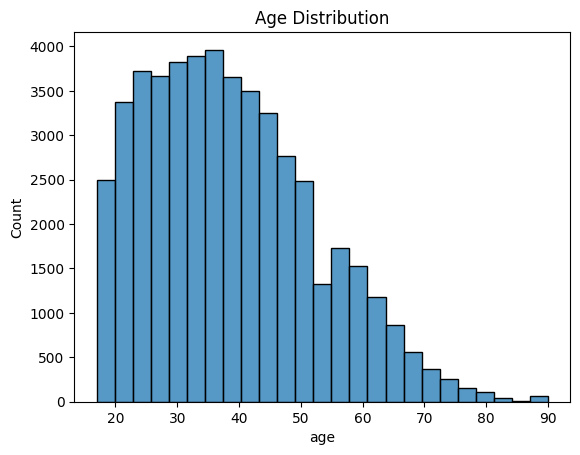

In [ ]:
sns.histplot(data=df, x="age", bins=25)
plt.title("Age Distribution")
plt.show()


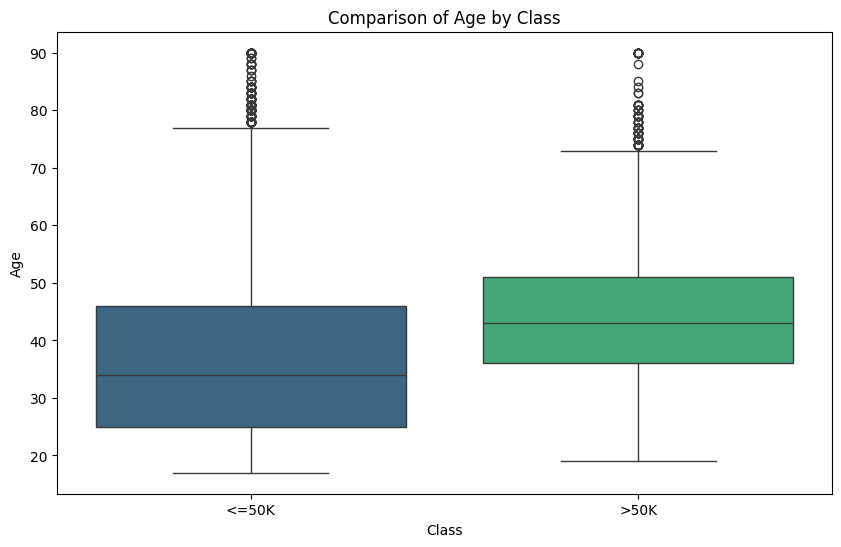

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='income', y='age', data=df, palette="viridis")

plt.title('Comparison of Age by Class')
plt.xlabel('Class')
plt.ylabel('Age')

plt.show()

In [ ]:
x = df.groupby("workclass")["age"].mean()
x

,age
workclass,
Federal-gov,42.577514
Local-gov,41.676020
Never-worked,19.900000
Private,36.911843
Self-emp-inc,45.815821
Self-emp-not-inc,45.331520
State-gov,39.512367
Unknown,40.166369
Without-pay,47.285714


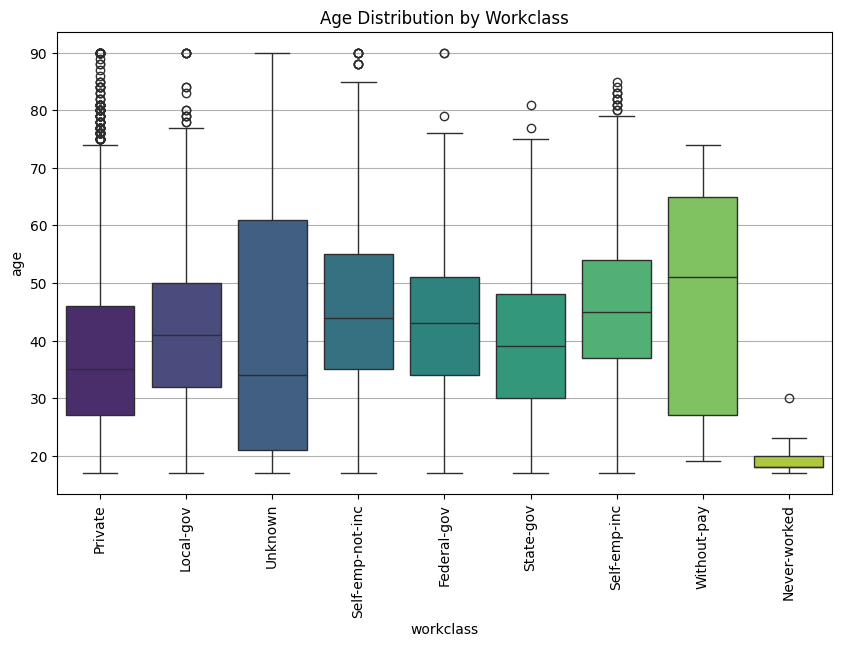

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="workclass", y="age", data=df, palette="viridis")
plt.title("Age Distribution by Workclass")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

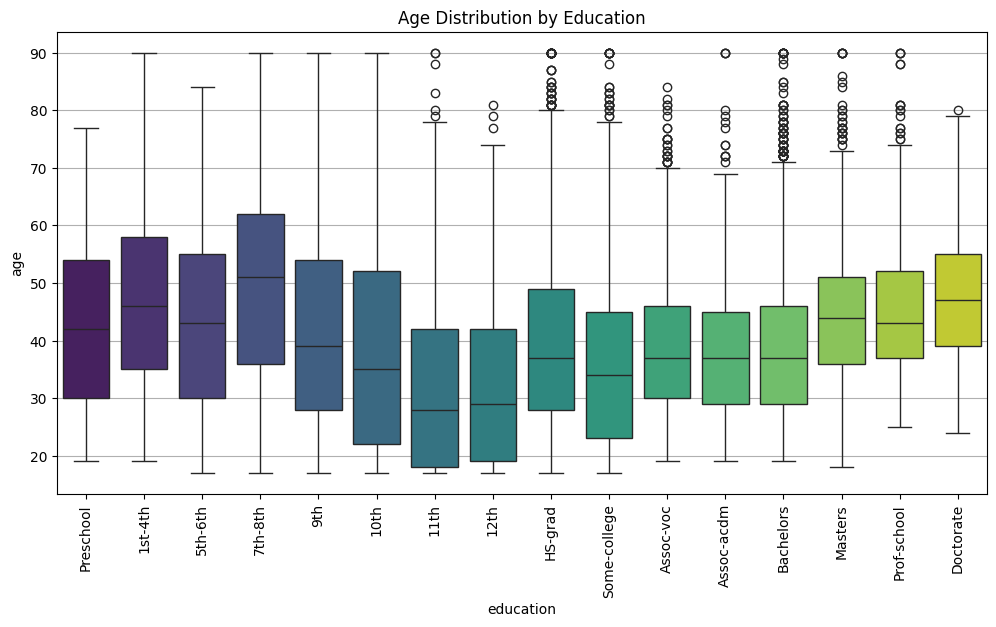

In [ ]:
plt.figure(figsize=(12, 6))

order = df.sort_values("educational-num")["education"].unique()

sns.boxplot(data=df, x="education", y="age", order=order, palette="viridis")

plt.title("Age Distribution by Education")
plt.xticks(rotation=90)
plt.grid(axis="y")

plt.show()

## workclass

### Workclass Description

| Workclass | Meaning |
|---|---|
| **Private** | Employed by a private company or organization. |
| **Self-emp-not-inc** | Self-employed in a business that is **not incorporated**. |
| **Local-gov** | Working for a **local government** entity (city or municipality). |
| **State-gov** | Working for a **state government** organization. |
| **Federal-gov** | Working for the **federal government**. |
| **Self-emp-inc** | Self-employed in an **incorporated business** (registered company). |
| **Without-pay** | Working without salary (e.g., volunteering in a family business). |
| **Never-worked** | The individual has **never worked before**. |
| **Unknown** | Workclass information is **missing or not specified**. |

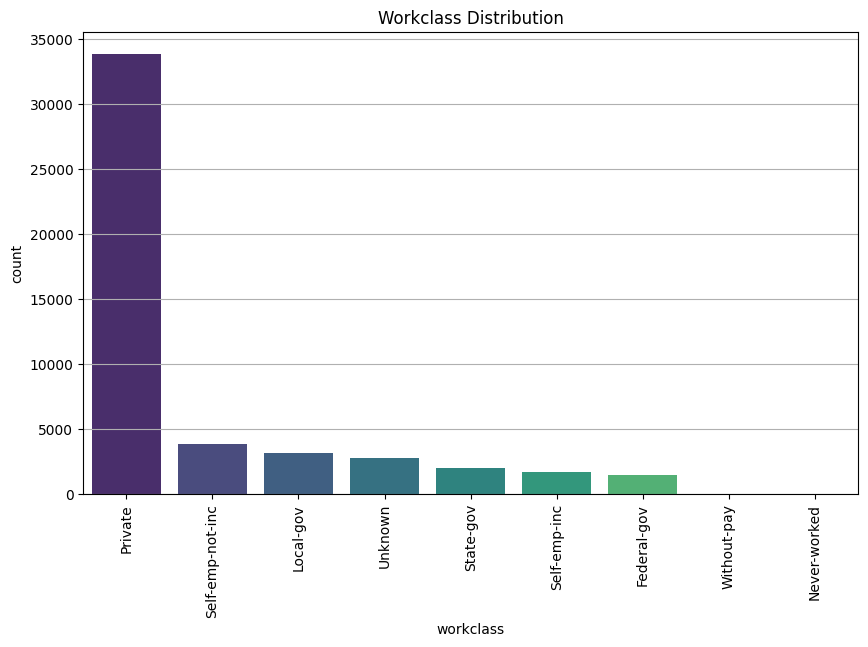

In [ ]:
x = df.workclass.value_counts().reset_index()
x = x.sort_values(by="count", ascending=False)
x

plt.figure(figsize=(10, 6))
sns.barplot(data=x, x="workclass", y="count", palette="viridis")
plt.title("Workclass Distribution")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

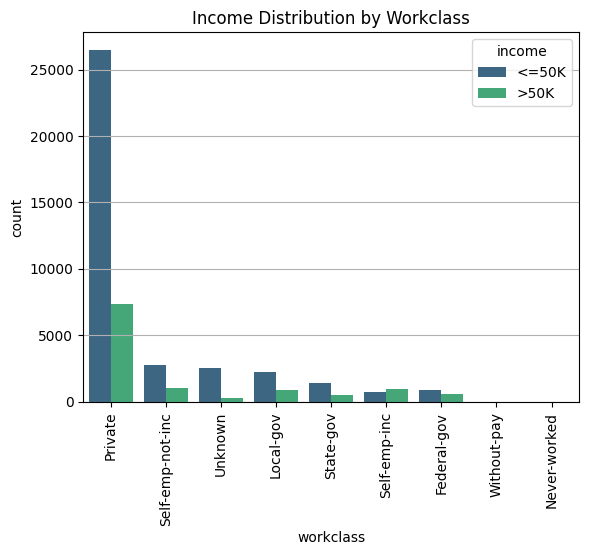

In [ ]:
x = df.pivot_table(index="workclass", columns="income", aggfunc="size").reset_index()
x = x.melt(id_vars="workclass", var_name="income", value_name="count")
x = x.sort_values(by="count", ascending=False)

sns.barplot(data=x, x="workclass", y="count", palette="viridis", hue="income")
plt.title("Income Distribution by Workclass")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

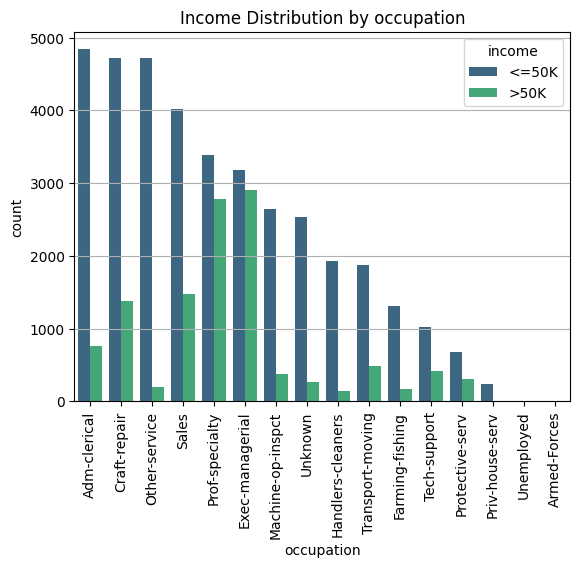

In [ ]:
x = df.pivot_table(index="occupation", columns="income", aggfunc="size").reset_index()
x = x.melt(id_vars="occupation", var_name="income", value_name="count")
x = x.sort_values(by="count", ascending=False)

sns.barplot(data=x, x="occupation", y="count", palette="viridis", hue="income")
plt.title("Income Distribution by occupation")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

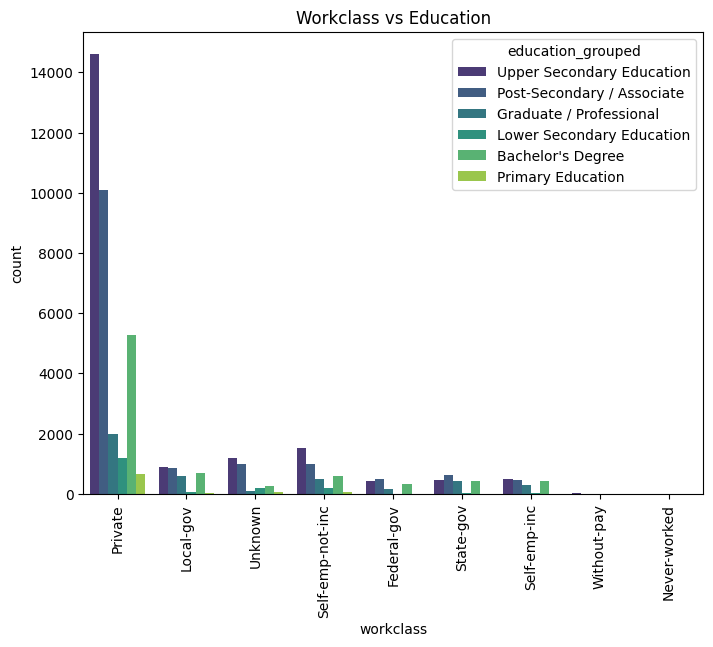

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="workclass", hue="education_grouped", palette="viridis")

plt.title("Workclass vs Education")
plt.xticks(rotation=90)
plt.show()

## education & educational-num

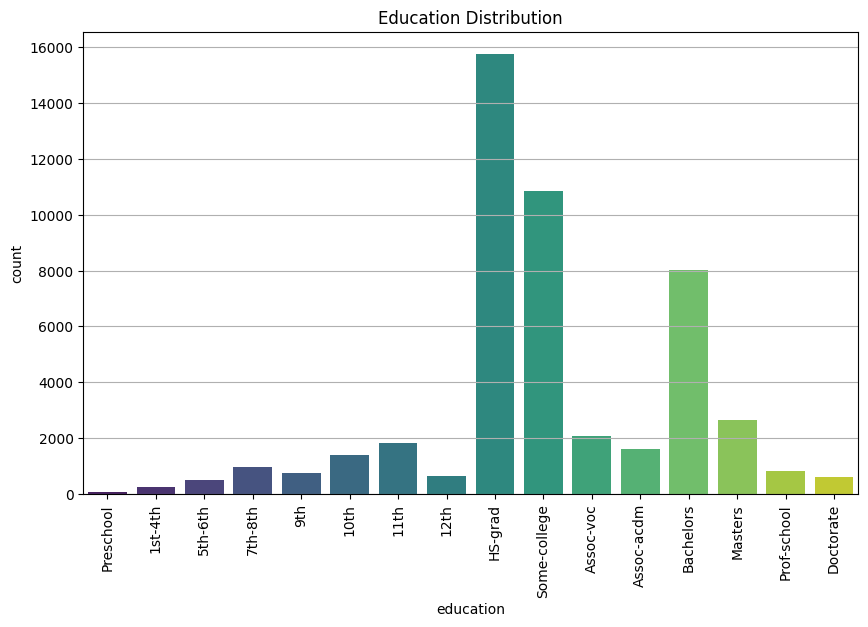

In [ ]:
order = df.sort_values(by="educational-num")["education"].unique()

x = df.education.value_counts().reset_index()
x.columns = ["education", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=x, x="education", y="count", palette="viridis", order=order)
plt.title("Education Distribution")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()



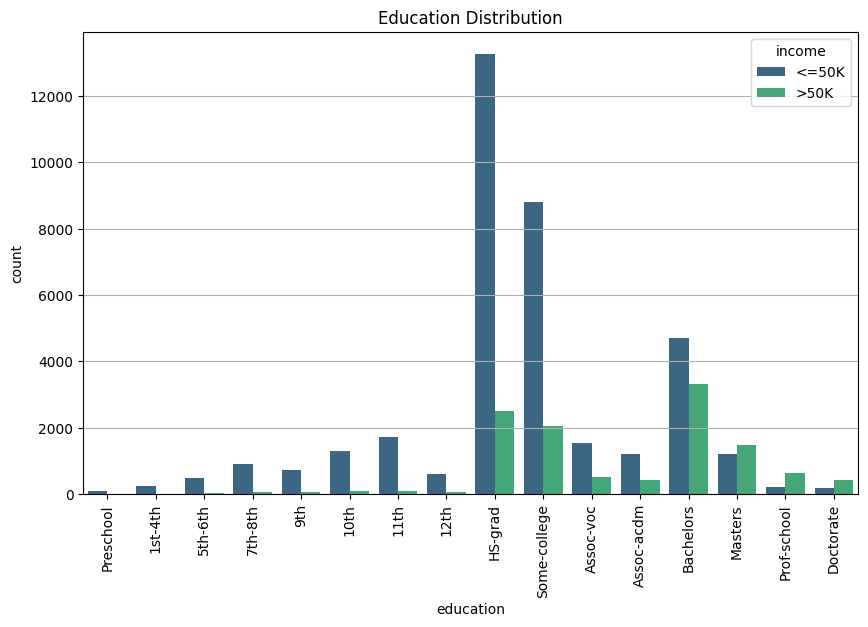

In [ ]:
order = df.sort_values(by="educational-num")["education"].unique()

x = df.pivot_table(index="education", columns="income", aggfunc="size").reset_index()
x = x.melt(id_vars="education", var_name="income", value_name="count")
x = x.sort_values(by="count", ascending=False)
x

plt.figure(figsize=(10, 6))
sns.barplot(data=x, x="education", y="count", hue="income", palette="viridis", order=order)
plt.title("Education Distribution")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()



## marital-status

### Marital Status Description

| Marital Status | Meaning |
|---|---|
| **Married-civ-spouse** | Married with spouse present in a civil marriage. |
| **Never-married** | The individual has never been married. |
| **Divorced** | Previously married but legally divorced. |
| **Separated** | Married but currently living separately from the spouse (not legally divorced). |
| **Widowed** | The spouse has passed away. |
| **Married-spouse-absent** | Married but the spouse is not currently living with the individual. |
| **Married-AF-spouse** | Married to a spouse serving in the Armed Forces. |

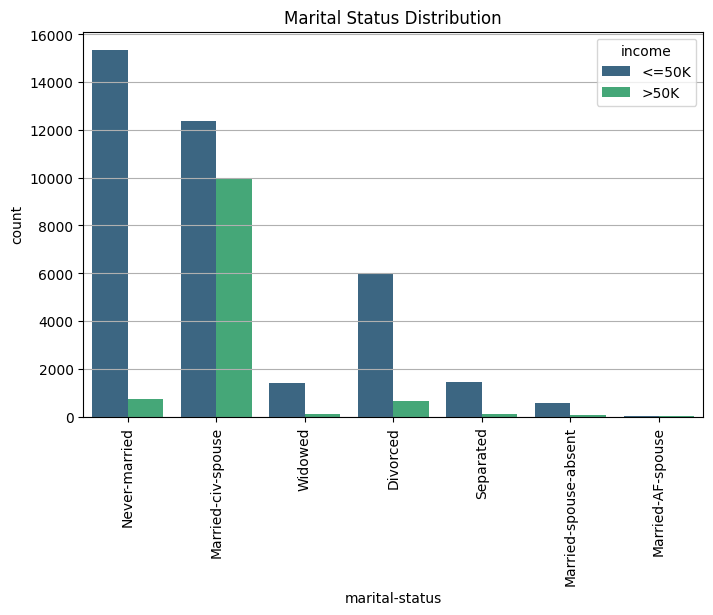

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="marital-status", hue="income", palette="viridis")
plt.title("Marital Status Distribution")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

## occupation

### Occupation Description

| Category | Original Occupations | Description |
|---|---|---|
| **Management & Executive** | Exec-managerial | Senior management and executive roles responsible for decision making and organizational leadership. |
| **Professional & Technical** | Prof-specialty, Tech-support | Specialized professional or technical roles requiring higher education or technical expertise. |
| **Administrative & Clerical** | Adm-clerical | Office administration, clerical, and documentation-related roles. |
| **Sales & Customer Service** | Sales, Other-service | Sales positions and customer-facing service roles. |
| **Skilled Trades & Technical Labor** | Craft-repair, Machine-op-inspct | Skilled manual or technical jobs involving machinery, repair, or industrial work. |
| **Transportation & Logistics** | Transport-moving | Jobs related to transportation, delivery, and logistics operations. |
| **Manual Labor & Maintenance** | Handlers-cleaners | Physical labor roles such as cleaning, handling materials, and maintenance work. |
| **Agriculture & Fishing** | Farming-fishing | Occupations related to agriculture, farming, and fishing industries. |
| **Public Safety & Protection** | Protective-serv | Security, law enforcement, and protective services. |
| **Domestic Services** | Priv-house-serv | Household service roles such as domestic workers or caretakers. |
| **Military** | Armed-Forces | Employment within the armed forces. |
| **Unemployed / Not Working** | Unemployed | Individuals currently without employment. |
| **Unknown** | Unknown | Occupation information is missing or unspecified. |

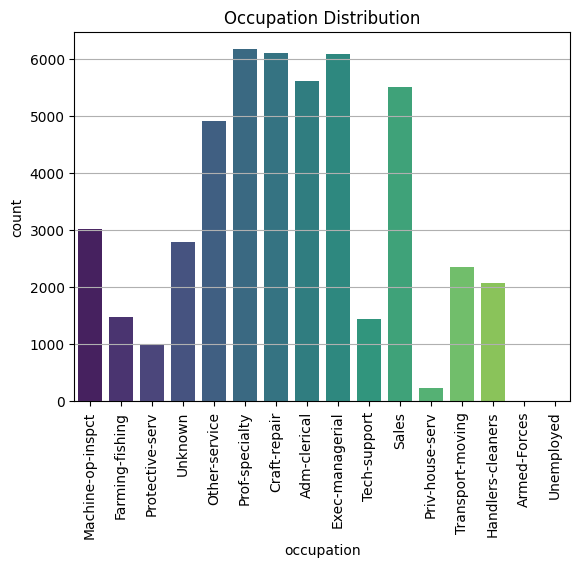

In [ ]:
sns.countplot(data=df, x="occupation", palette="viridis")
plt.title("Occupation Distribution")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

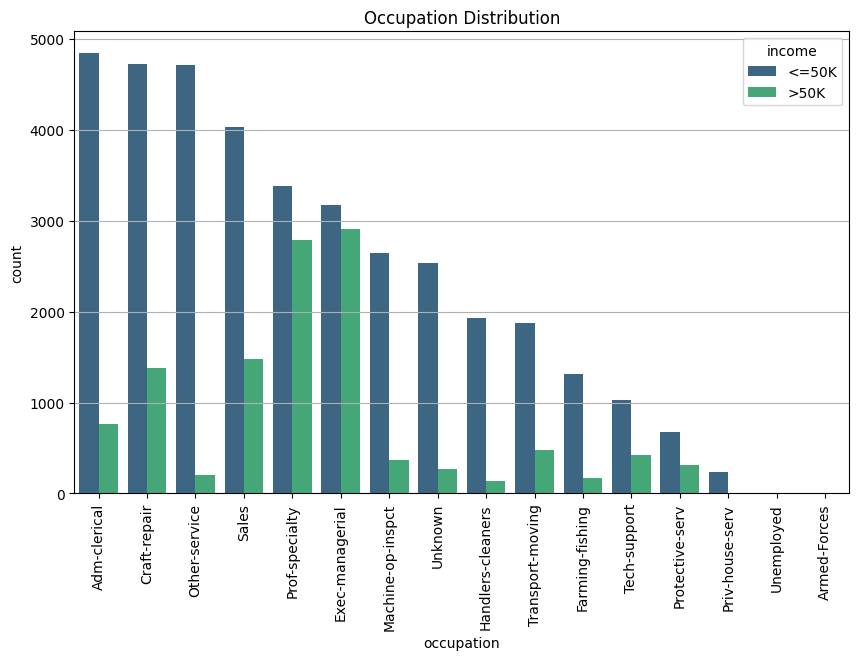

In [ ]:
x = df.pivot_table(index="occupation", columns="income", aggfunc="size").reset_index()
x = x.melt(id_vars="occupation", var_name="income", value_name="count")
x = x.sort_values(by="count", ascending=False)
x

plt.figure(figsize=(10, 6))
sns.barplot(data=x, x="occupation", y="count", hue="income", palette="viridis")
plt.title("Occupation Distribution")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

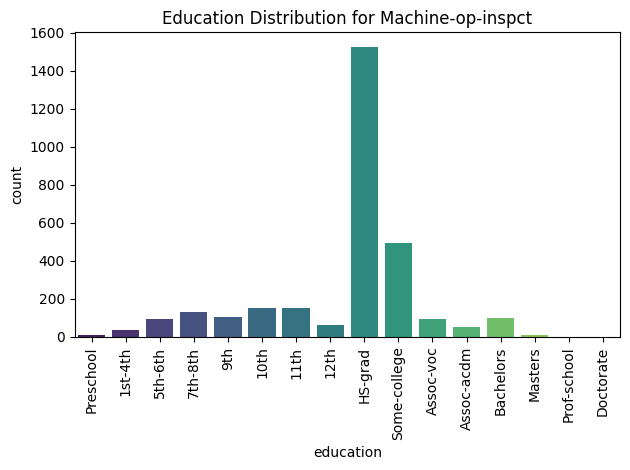

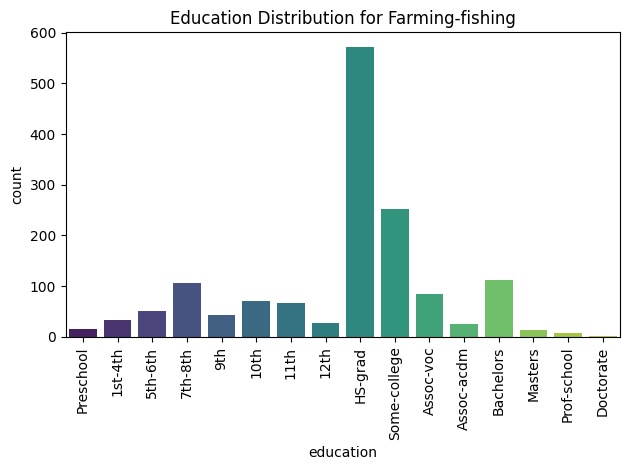

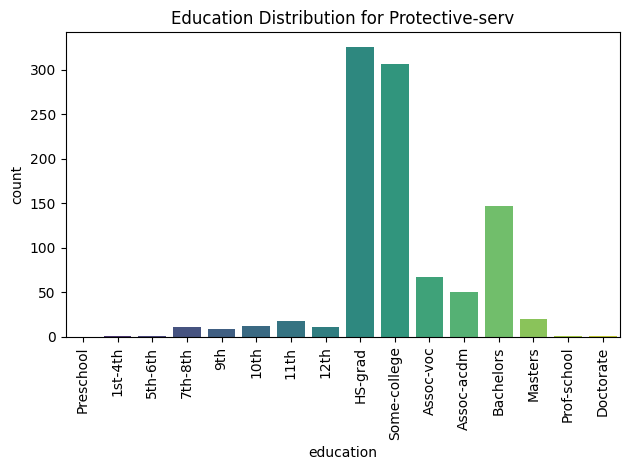

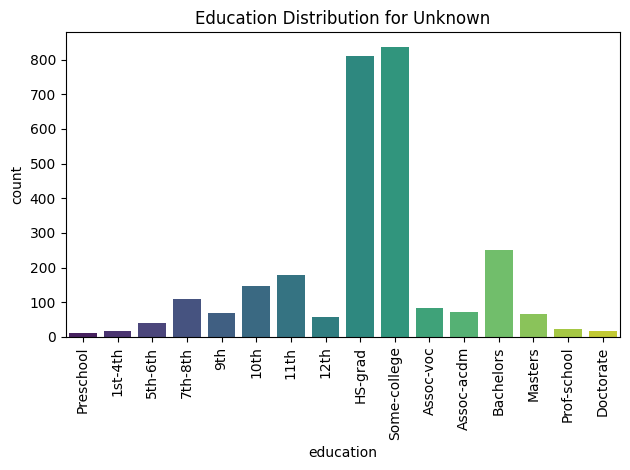

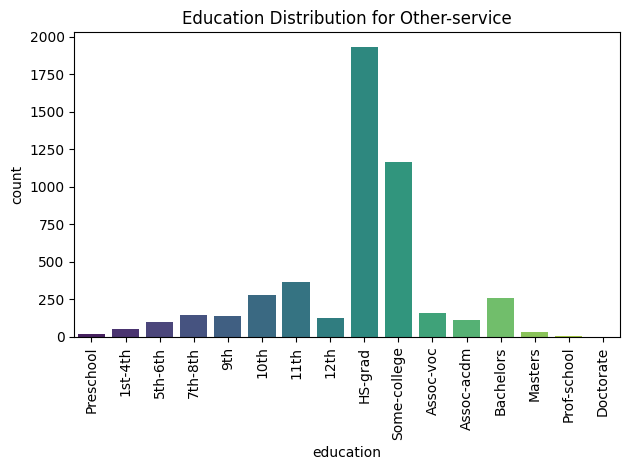

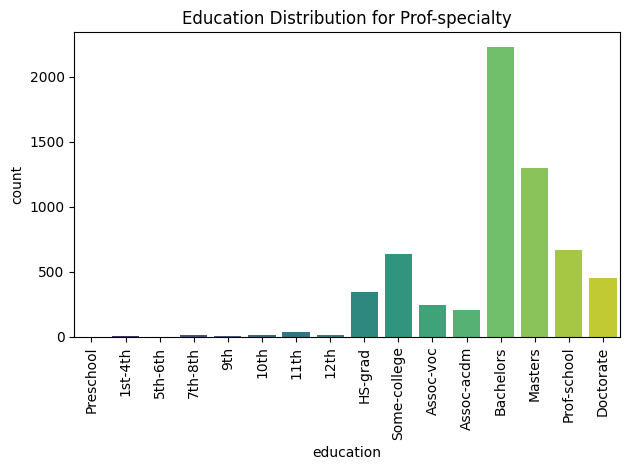

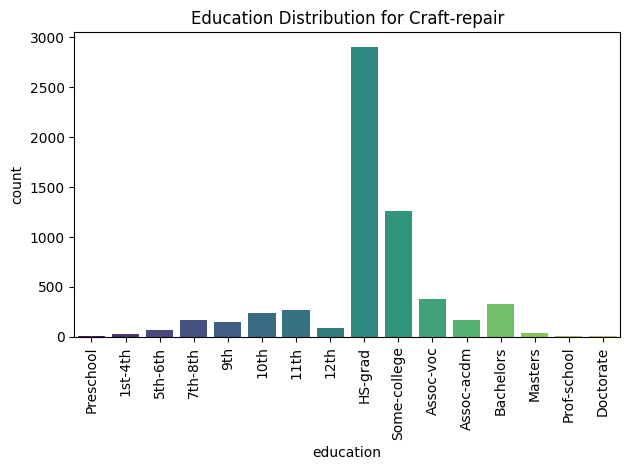

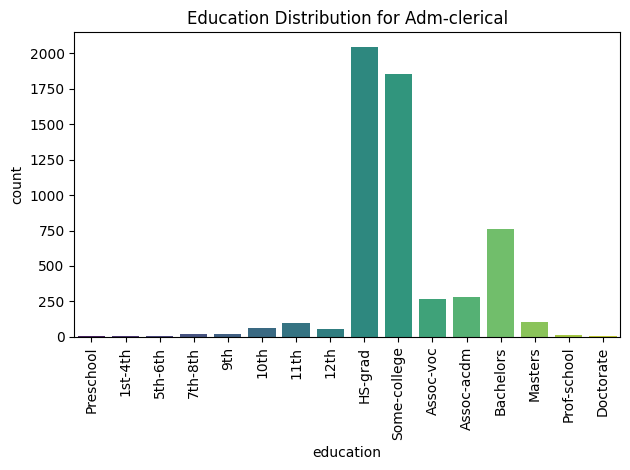

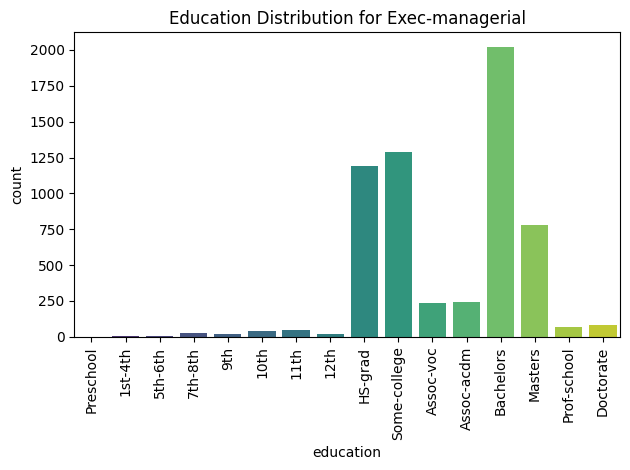

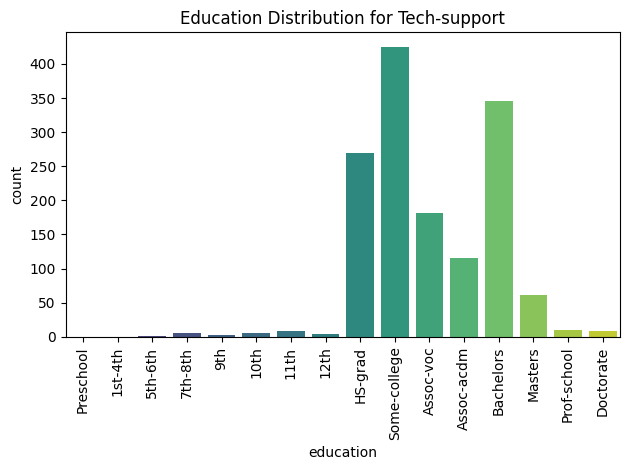

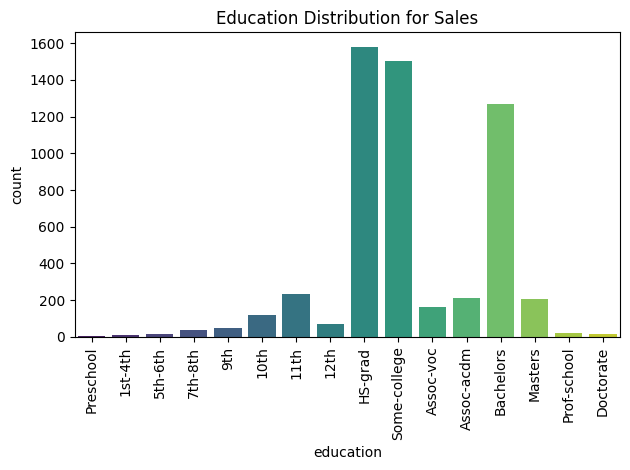

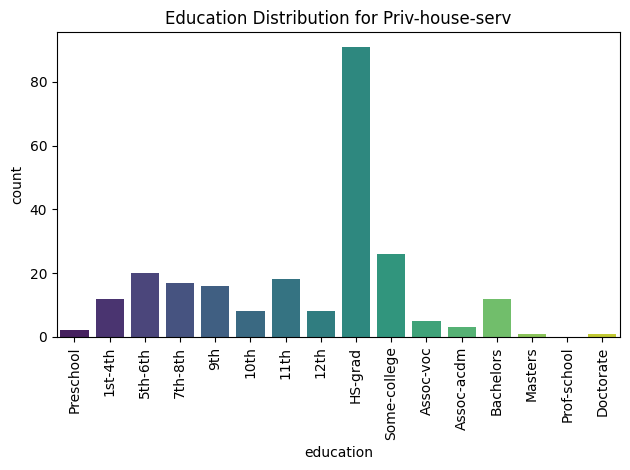

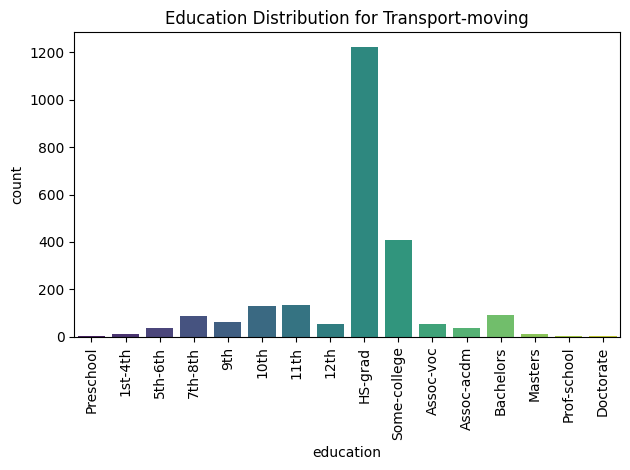

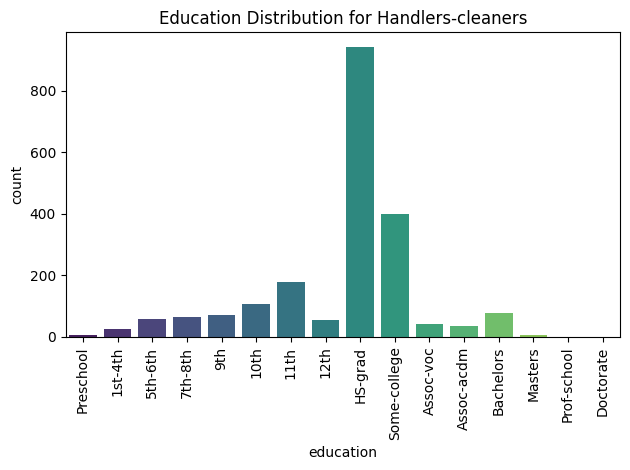

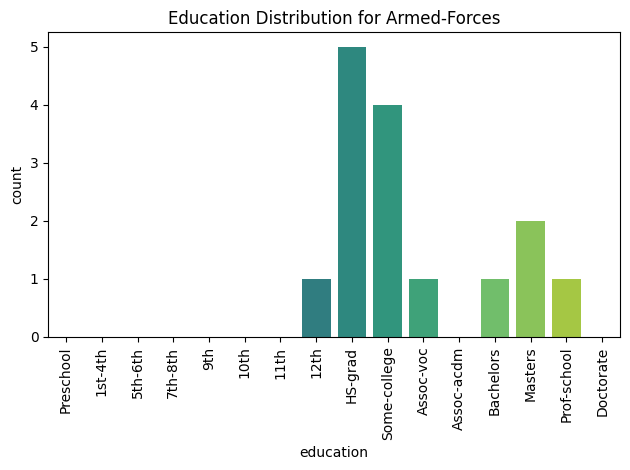

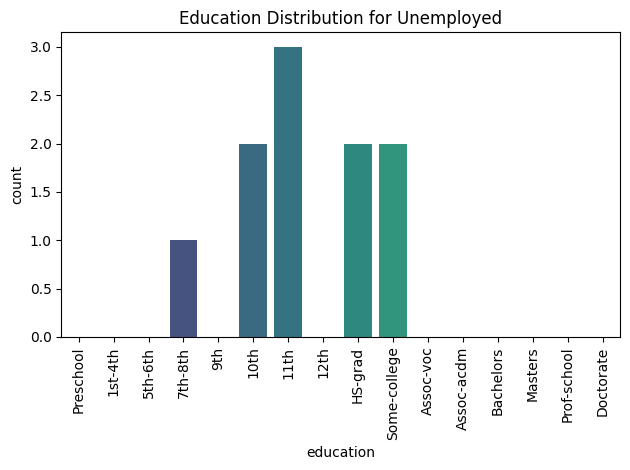

In [ ]:
order = df.sort_values(by="educational-num")["education"].unique()

for i in df.occupation.unique():
    sns.countplot(data=df.loc[df.occupation == i], x="education", palette="viridis", order=order)
    plt.title(f"Education Distribution for {i}")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

## relationship

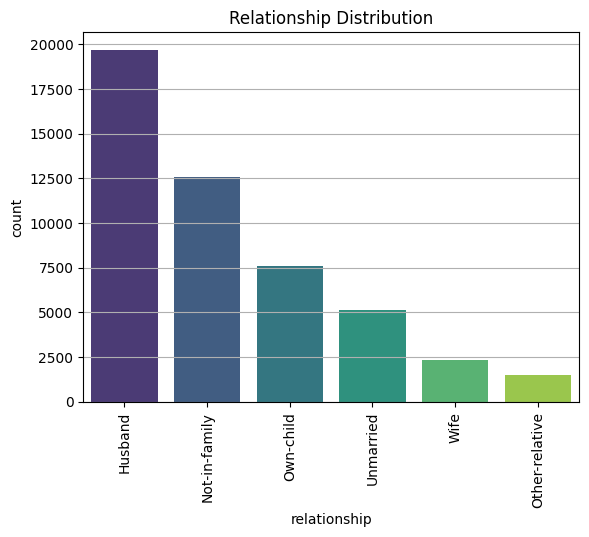

In [ ]:
order = df["relationship"].value_counts().index

sns.countplot(data=df, x="relationship", palette="viridis", order=order)
plt.title("Relationship Distribution")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

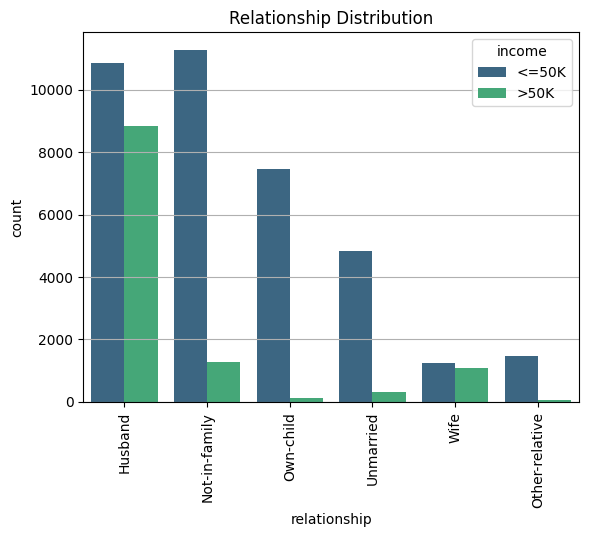

In [ ]:
order = df["relationship"].value_counts().index

sns.countplot(data=df, x="relationship", hue="income", palette="viridis", order=order)
plt.title("Relationship Distribution")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

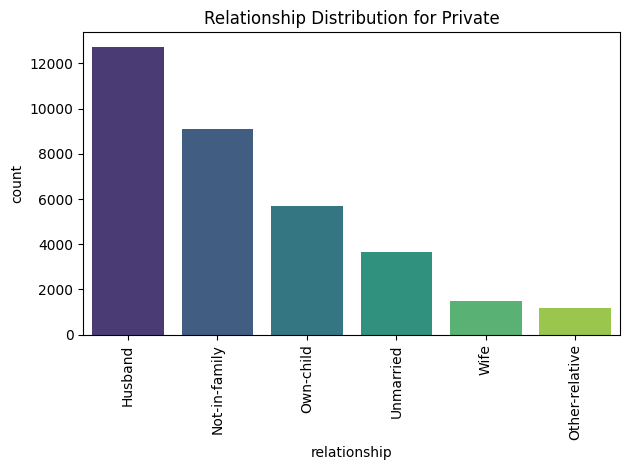

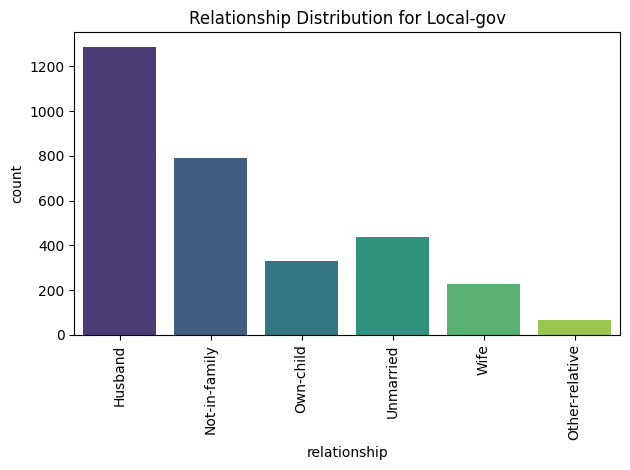

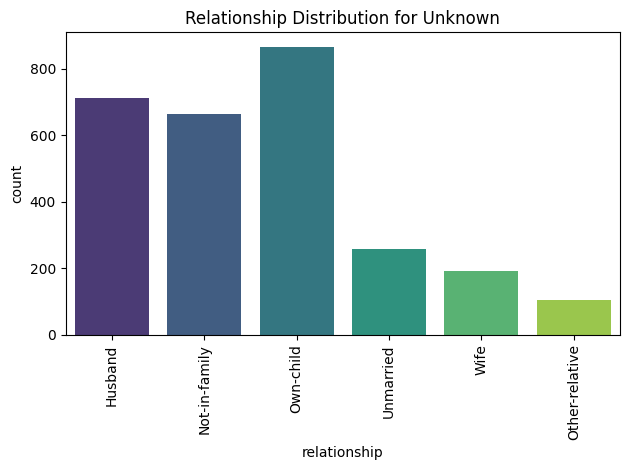

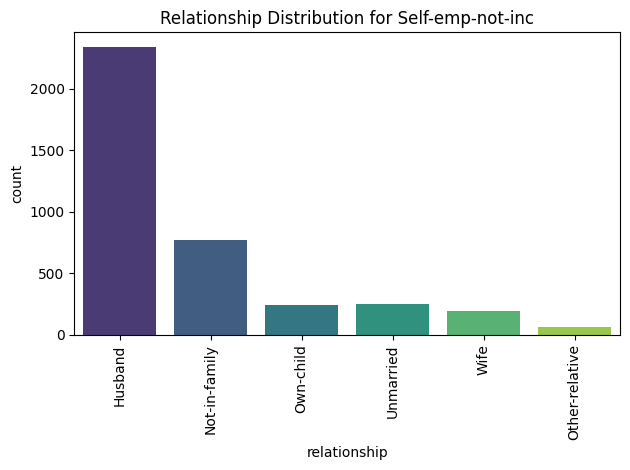

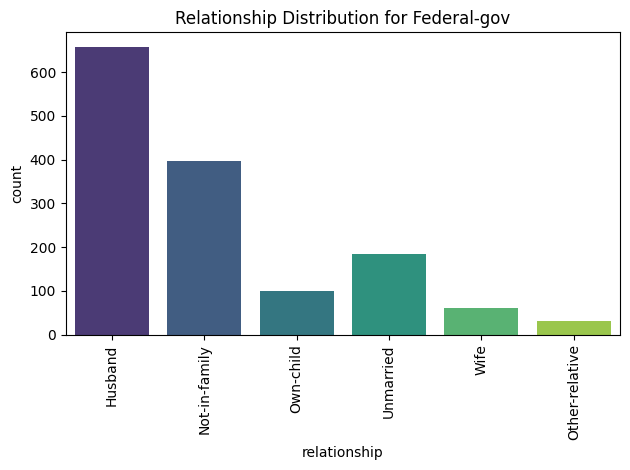

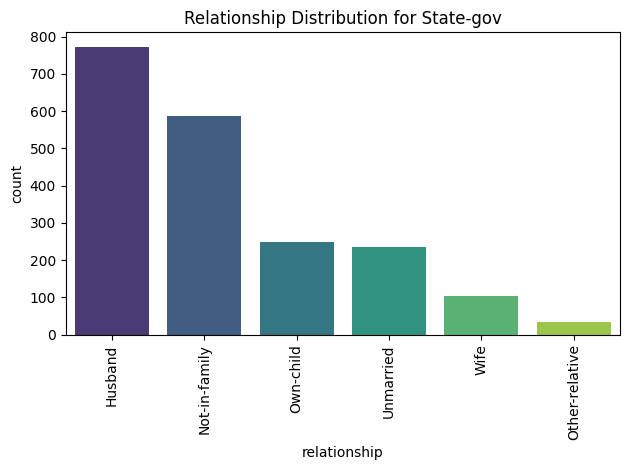

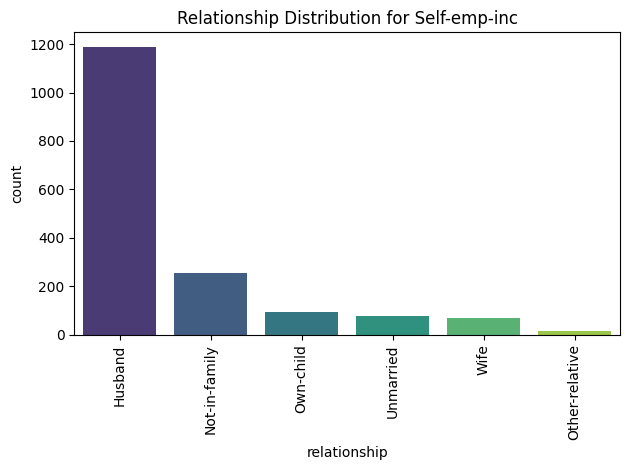

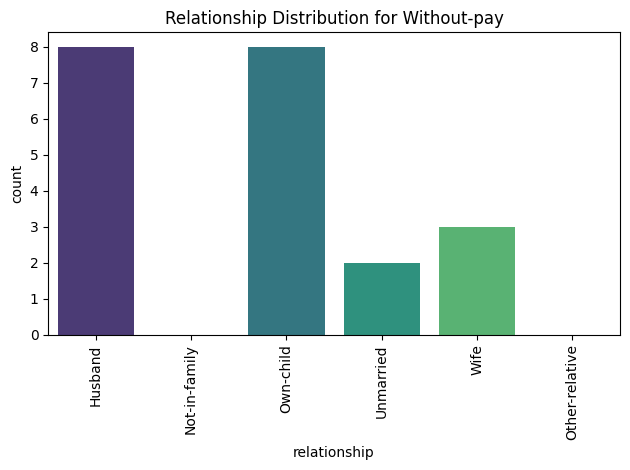

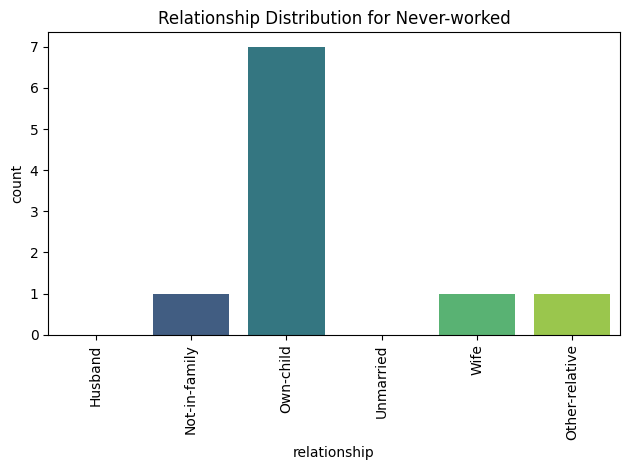

In [ ]:
order = df["relationship"].value_counts().index

for i in df.workclass.unique():
    sns.countplot(data=df.loc[df.workclass == i], x="relationship", palette="viridis", order=order)
    plt.title(f"Relationship Distribution for {i}")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

## race

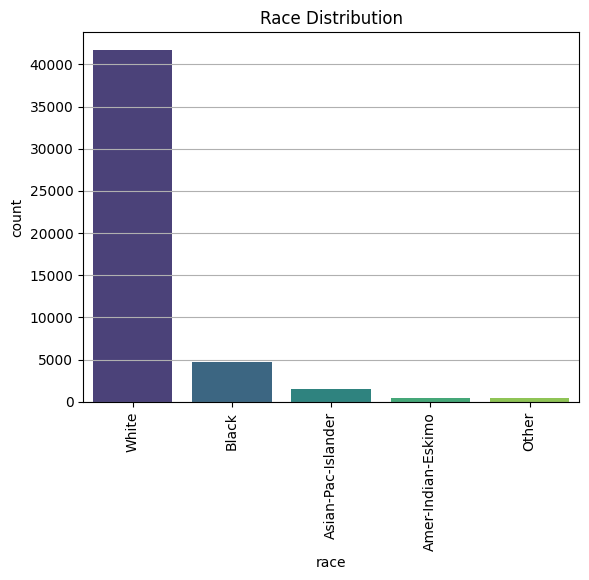

In [ ]:
order = df["race"].value_counts().index

sns.countplot(data=df, x="race", palette="viridis", order=order)
plt.title("Race Distribution")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

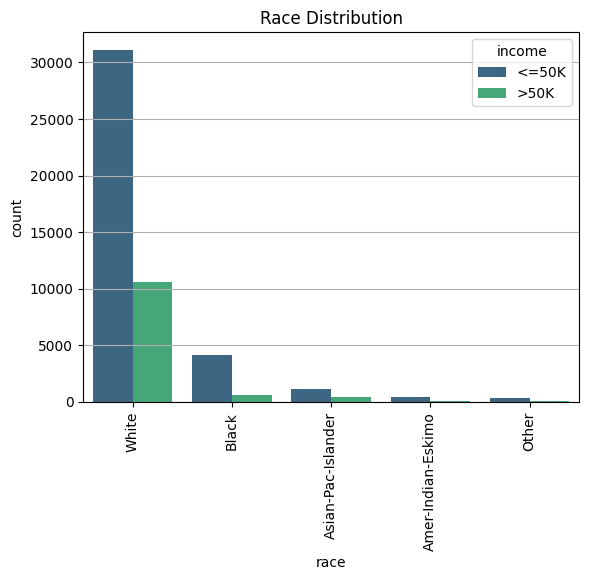

In [ ]:
order = df["race"].value_counts().index

sns.countplot(data=df, x="race", hue="income", palette="viridis", order=order)
plt.title("Race Distribution")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

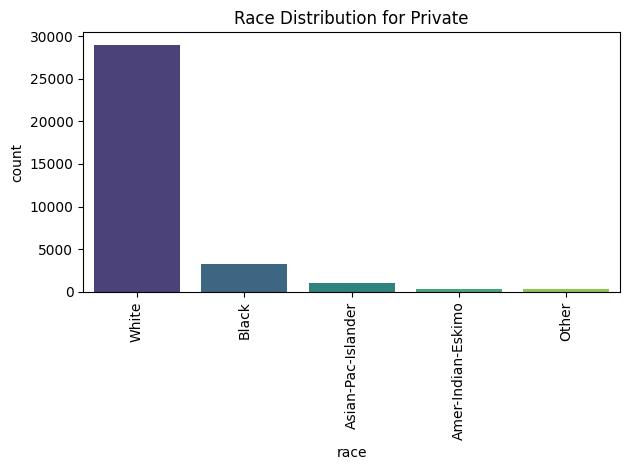

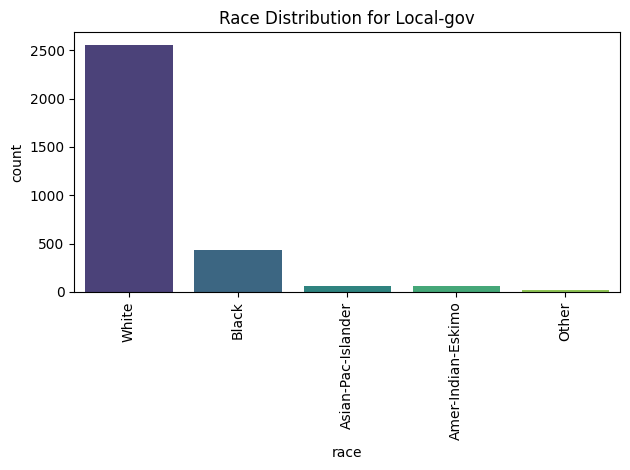

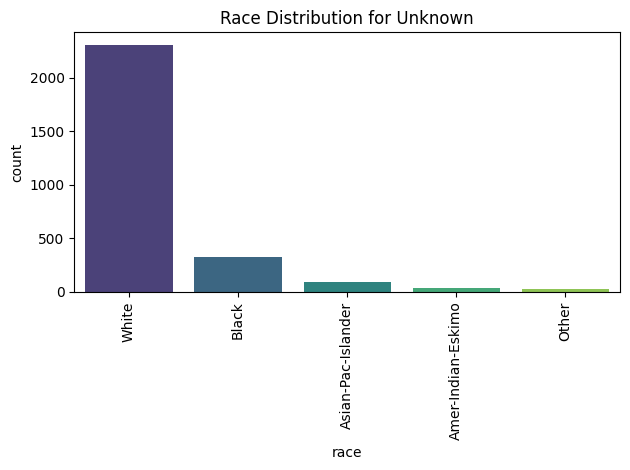

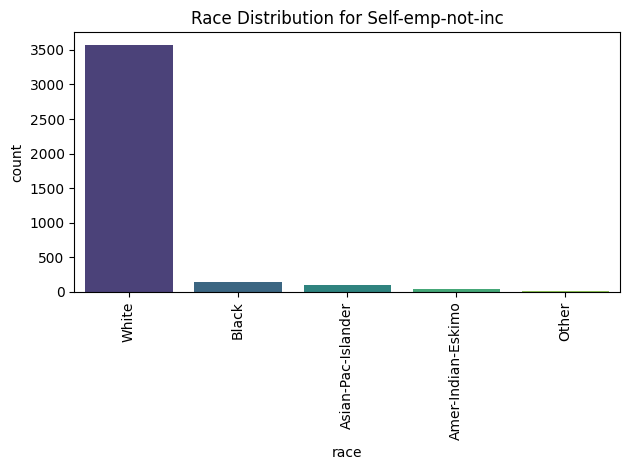

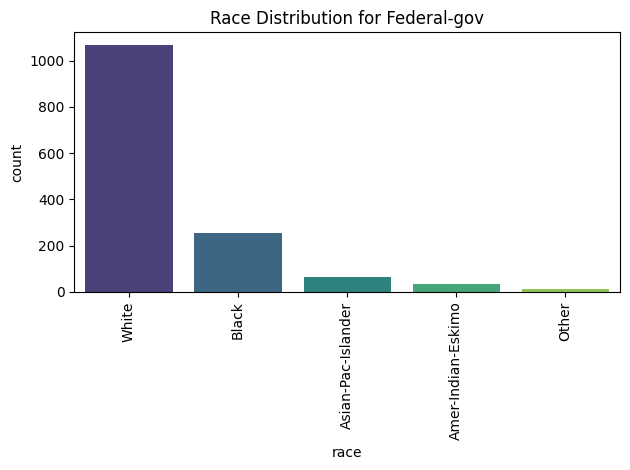

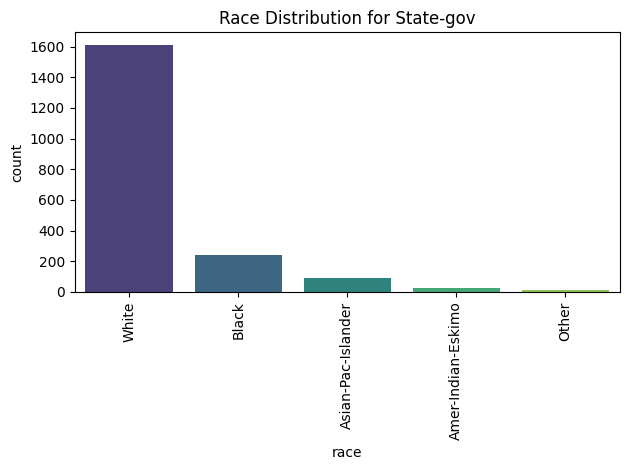

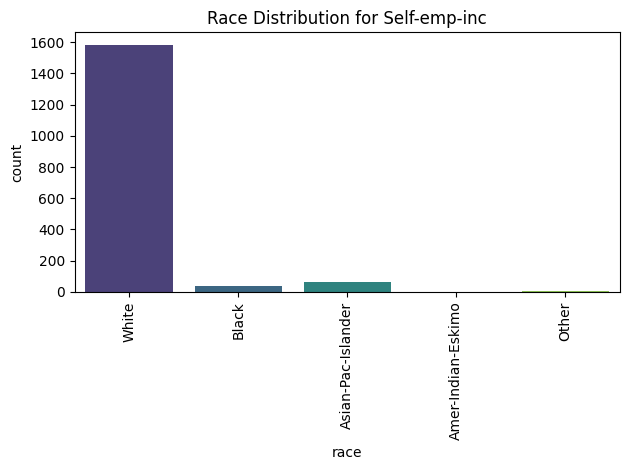

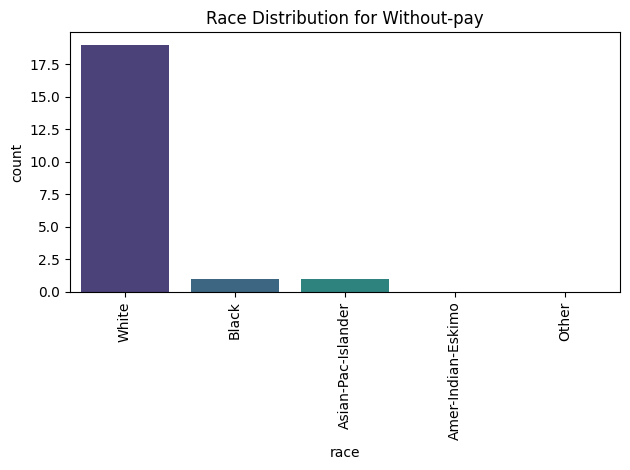

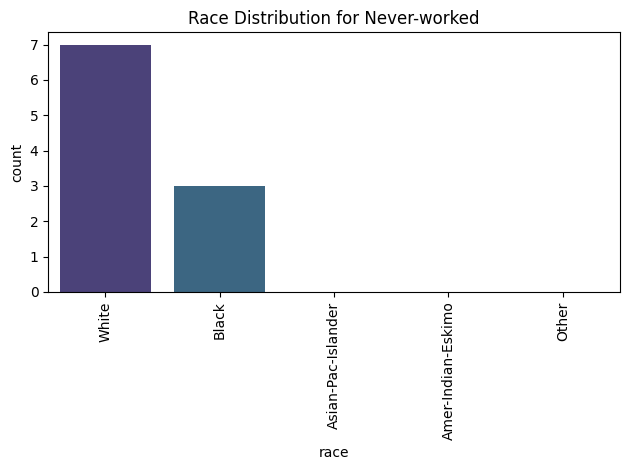

In [ ]:
order = df["race"].value_counts().index

for i in df.workclass.unique():
    sns.countplot(data=df.loc[df.workclass == i], x="race", palette="viridis", order=order)
    plt.title(f"Race Distribution for {i}")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

## gender

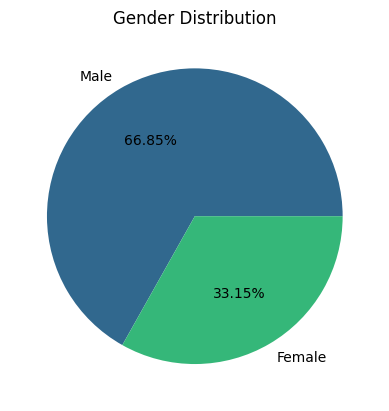

In [ ]:
x = df.gender.value_counts()
x

colors = sns.color_palette("viridis", 2)

plt.pie(x, labels=x.index, colors=colors, autopct="%1.2f%%")
plt.title("Gender Distribution")
plt.show()

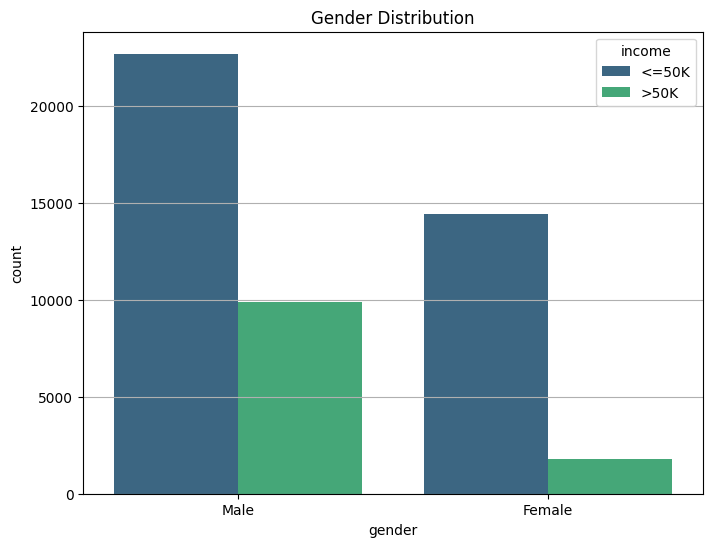

In [ ]:
x = df.pivot_table(index="gender", columns="income", aggfunc="size").reset_index()
x = x.melt(id_vars="gender", var_name="income", value_name="count")
x = x.sort_values(by="count", ascending=False)
x

plt.figure(figsize=(8, 6))
sns.barplot(data=x, x="gender", y="count", hue="income", palette="viridis")
plt.title("Gender Distribution")
plt.grid(axis="y")
plt.show()

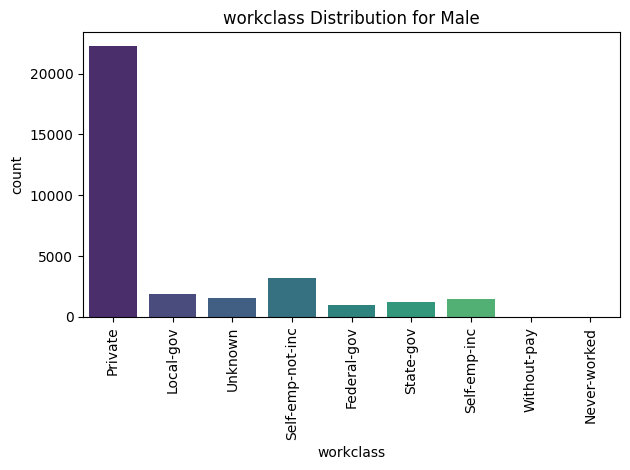

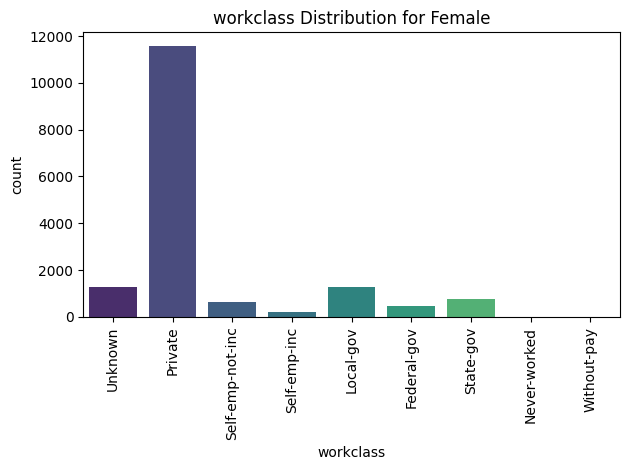

In [ ]:
for i in df.gender.unique():
    sns.countplot(data=df.loc[df.gender == i], x="workclass", palette="viridis")
    plt.title(f"workclass Distribution for {i}")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

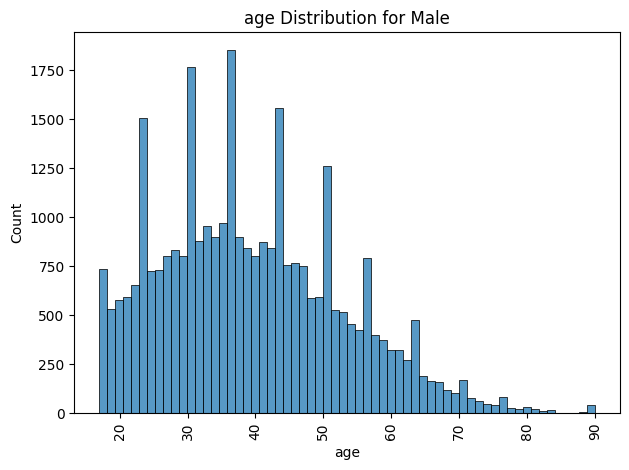

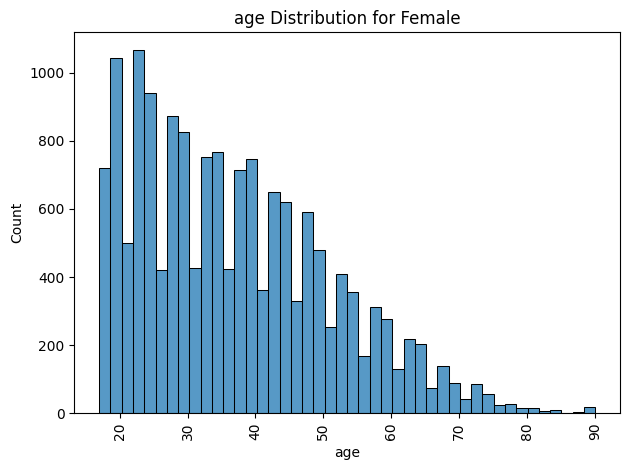

In [ ]:
for i in df.gender.unique():
    sns.histplot(data=df.loc[df.gender == i], x="age", palette="viridis")
    plt.title(f"age Distribution for {i}")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

## capital-gain & capital-loss

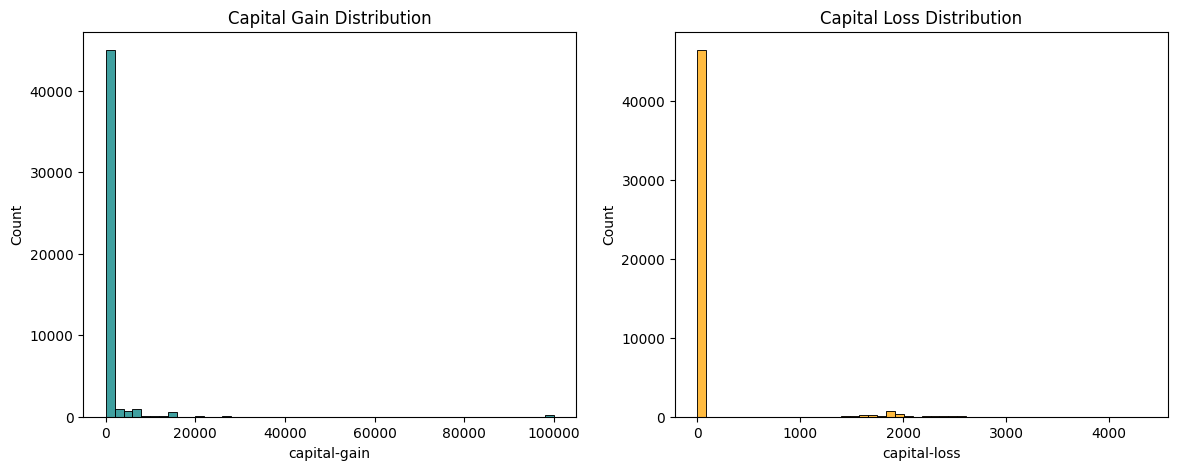

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.histplot(df["capital-gain"], bins=50, ax=ax[0], color="teal")
ax[0].set_title("Capital Gain Distribution")

sns.histplot(df["capital-loss"], bins=50, ax=ax[1], color="orange")
ax[1].set_title("Capital Loss Distribution")

plt.show()

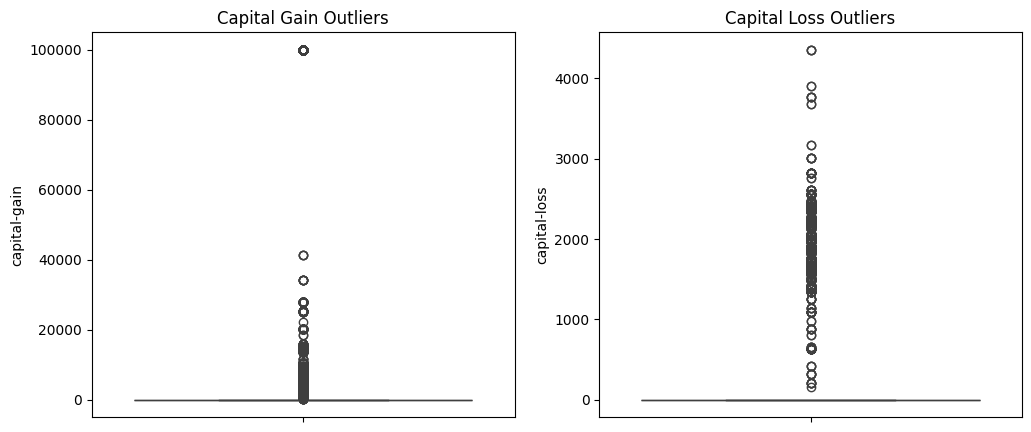

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(y=df["capital-gain"], ax=ax[0])
ax[0].set_title("Capital Gain Outliers")

sns.boxplot(y=df["capital-loss"], ax=ax[1])
ax[1].set_title("Capital Loss Outliers")

plt.show()

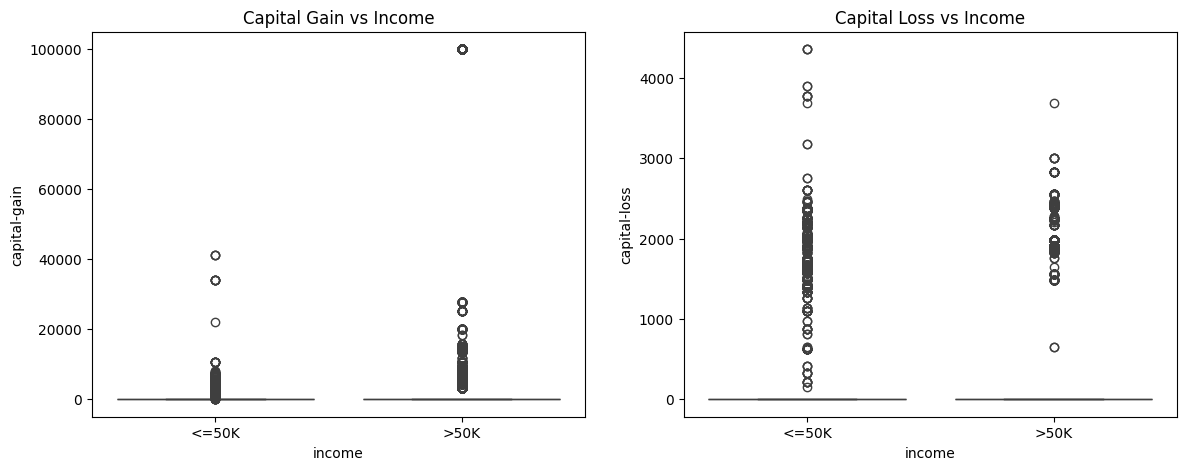

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(data=df, x="income", y="capital-gain", ax=ax[0])
ax[0].set_title("Capital Gain vs Income")

sns.boxplot(data=df, x="income", y="capital-loss", ax=ax[1])
ax[1].set_title("Capital Loss vs Income")

plt.show()

## hours-per-week

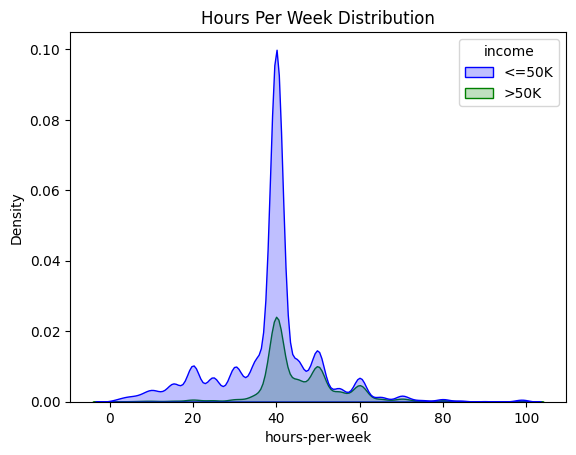

In [ ]:
sns.kdeplot(data=df, x="hours-per-week",hue="income", fill=True, palette=["Blue","green"])
plt.title("Hours Per Week Distribution")
plt.show()

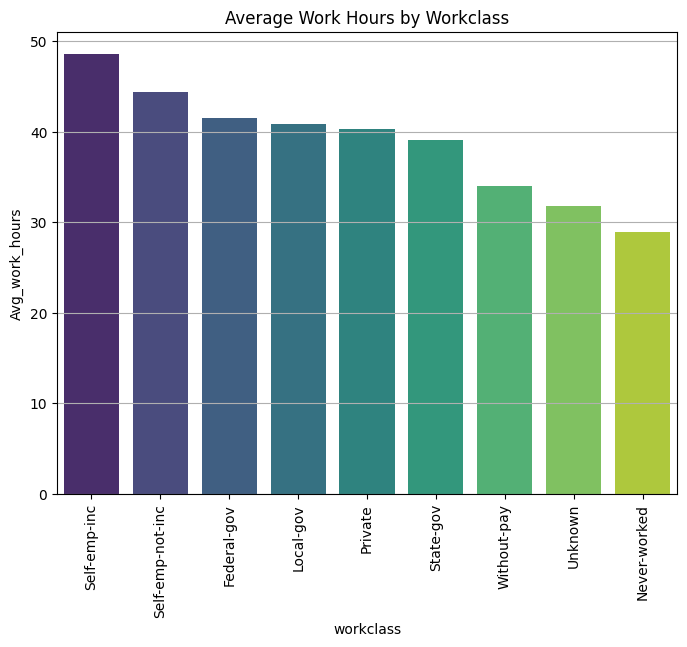

In [ ]:
x = df.groupby("workclass")["hours-per-week"].agg(["mean"]).reset_index()
x.columns = ["workclass", "Avg_work_hours"]
x = x.sort_values(by="Avg_work_hours", ascending=False)
x

plt.figure(figsize=(8, 6))
sns.barplot(data=x, x="workclass", y="Avg_work_hours", palette="viridis")
plt.title("Average Work Hours by Workclass")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

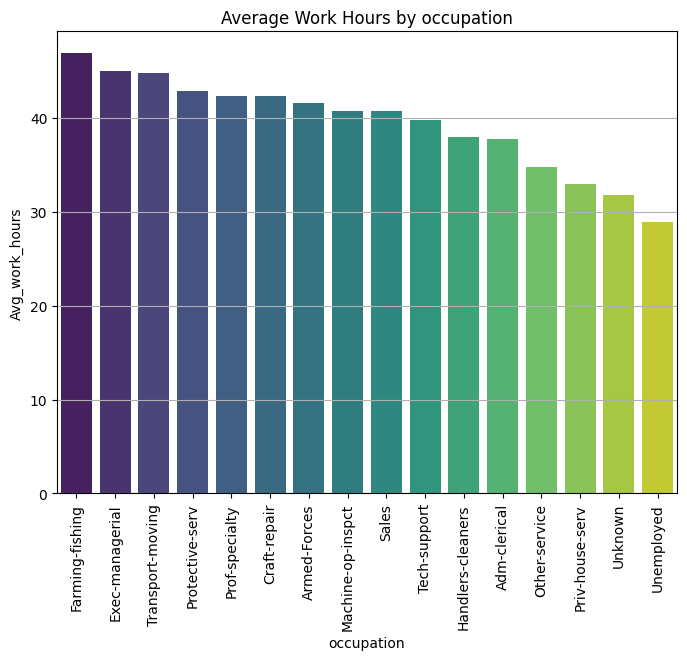

In [ ]:
x = df.groupby("occupation")["hours-per-week"].agg(["mean"]).reset_index()
x.columns = ["occupation", "Avg_work_hours"]
x = x.sort_values(by="Avg_work_hours", ascending=False)
x

plt.figure(figsize=(8, 6))
sns.barplot(data=x, x="occupation", y="Avg_work_hours", palette="viridis")
plt.title("Average Work Hours by occupation")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

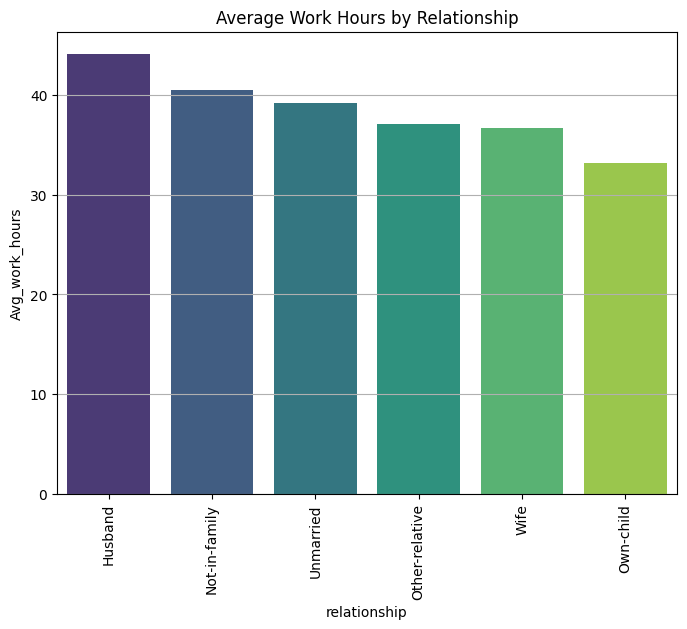

In [ ]:
x = df.groupby("relationship")["hours-per-week"].agg(["mean"]).reset_index()
x.columns = ["relationship", "Avg_work_hours"]
x = x.sort_values(by="Avg_work_hours", ascending=False)
x

plt.figure(figsize=(8, 6))
sns.barplot(data=x, x="relationship", y="Avg_work_hours", palette="viridis")
plt.title("Average Work Hours by Relationship")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

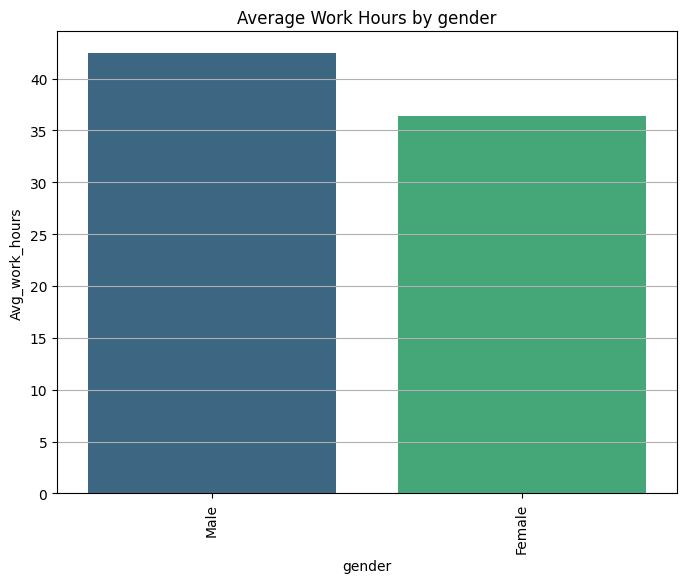

In [ ]:
x = df.groupby("gender")["hours-per-week"].agg(["mean"]).reset_index()
x.columns = ["gender", "Avg_work_hours"]
x = x.sort_values(by="Avg_work_hours", ascending=False)
x

plt.figure(figsize=(8, 6))
sns.barplot(data=x, x="gender", y="Avg_work_hours", palette="viridis")
plt.title("Average Work Hours by gender")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

## native-country

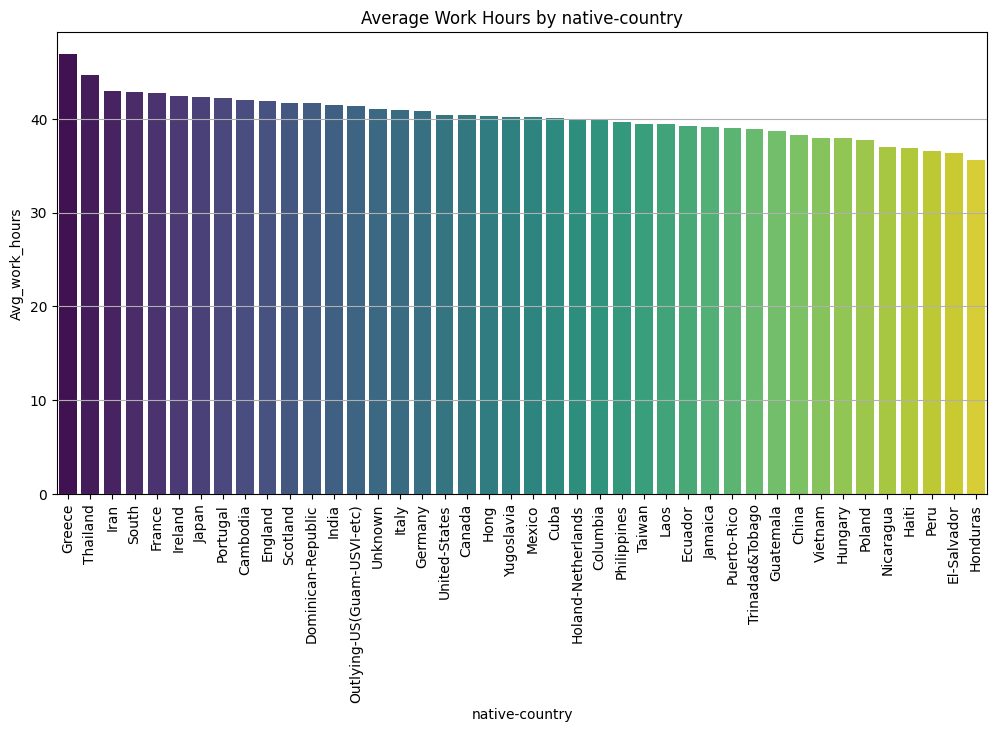

In [ ]:
x = df.groupby("native-country")["hours-per-week"].agg(["mean"]).reset_index()
x.columns = ["native-country", "Avg_work_hours"]
x = x.sort_values(by="Avg_work_hours", ascending=False)
x

plt.figure(figsize=(12, 6))
sns.barplot(data=x, x="native-country", y="Avg_work_hours", palette="viridis")
plt.title("Average Work Hours by native-country")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

In [ ]:
x = df.pivot_table(index="native-country", columns="income", aggfunc="size")
x = x.div(x.sum(axis=1), axis=0) * 100
x = x.round(2).reset_index()
x = x.replace(np.nan, 0)
x

income,native-country,<=50K,>50K
0,Cambodia,67.86,32.14
1,Canada,65.38,34.62
2,China,70.49,29.51
3,Columbia,95.29,4.71
4,Cuba,75.36,24.64
5,Dominican-Republic,95.15,4.85
6,Ecuador,86.67,13.33
7,El-Salvador,92.90,7.10
8,England,62.99,37.01
9,France,57.89,42.11


In [ ]:
x = df.pivot_table(index="native-country", columns="education_grouped", aggfunc="size")
x = x.div(x.sum(axis=1), axis=0) * 100
x = x.round(2).reset_index()
x = x.replace(np.nan, 0)
x

education_grouped,native-country,Bachelor's Degree,Graduate / Professional,Lower Secondary Education,Post-Secondary / Associate,Primary Education,Upper Secondary Education
0,Cambodia,17.86,0.00,3.57,35.71,7.14,35.71
1,Canada,20.88,13.74,4.40,26.92,0.55,33.52
2,China,23.77,32.79,5.74,7.38,4.10,26.23
3,Columbia,7.06,7.06,7.06,23.53,4.71,50.59
4,Cuba,13.77,12.32,9.42,23.19,9.42,31.88
5,Dominican-Republic,5.83,2.91,18.45,15.53,16.50,40.78
6,Ecuador,11.11,6.67,4.44,28.89,6.67,42.22
7,El-Salvador,5.16,3.23,13.55,14.84,31.61,31.61
8,England,26.77,17.32,0.79,18.90,1.57,34.65
9,France,26.32,28.95,2.63,26.32,0.00,15.79


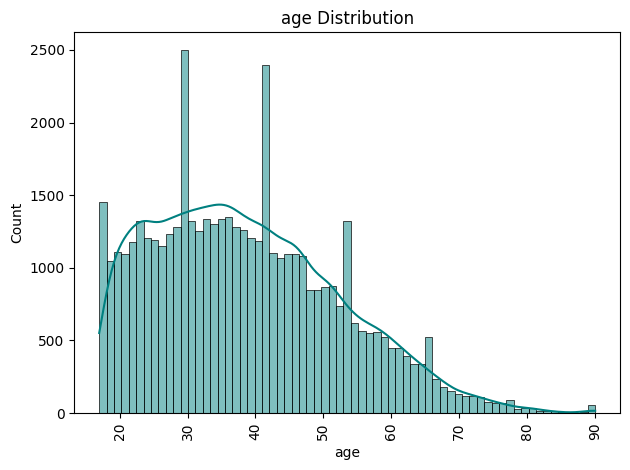

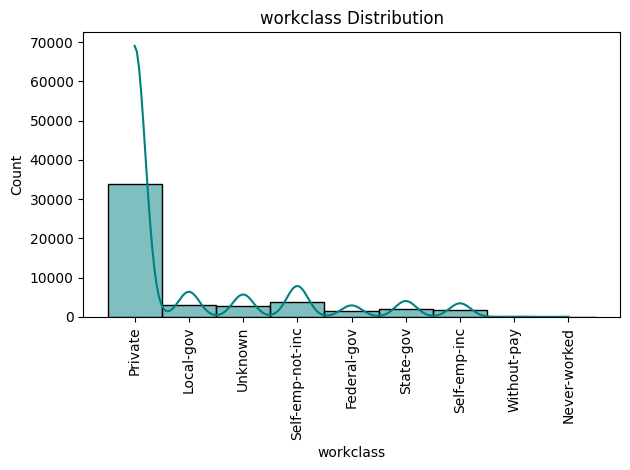

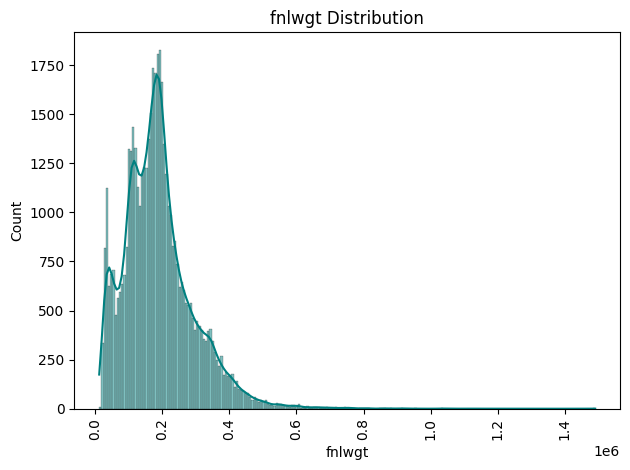

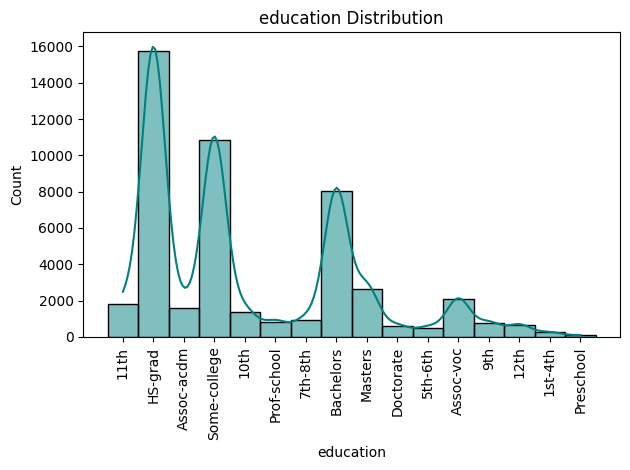

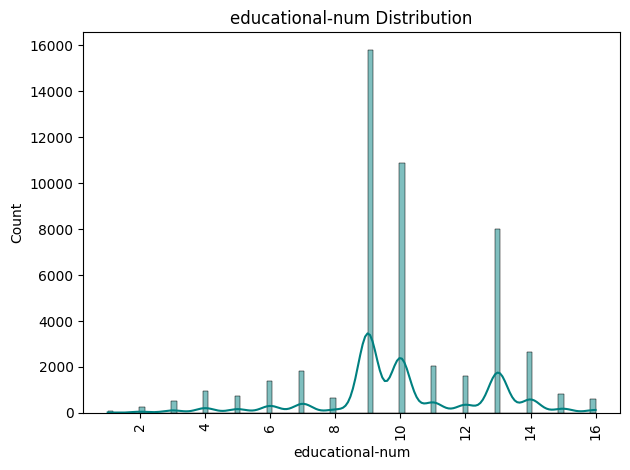

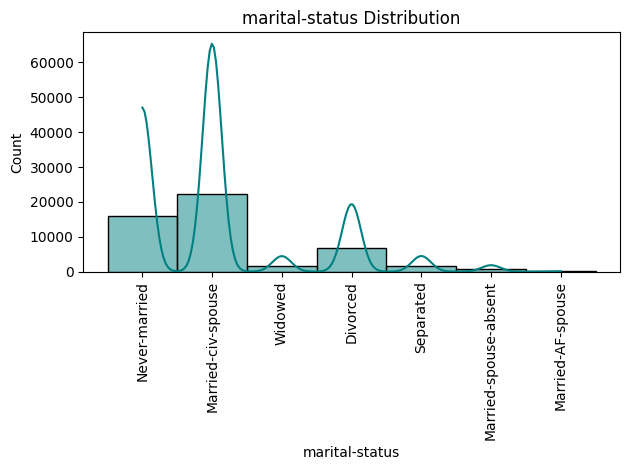

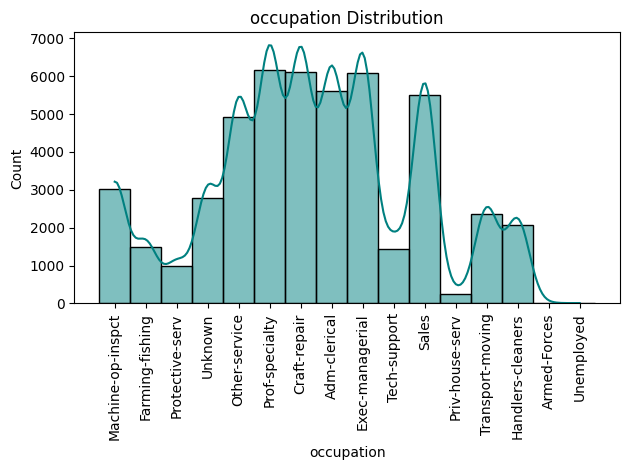

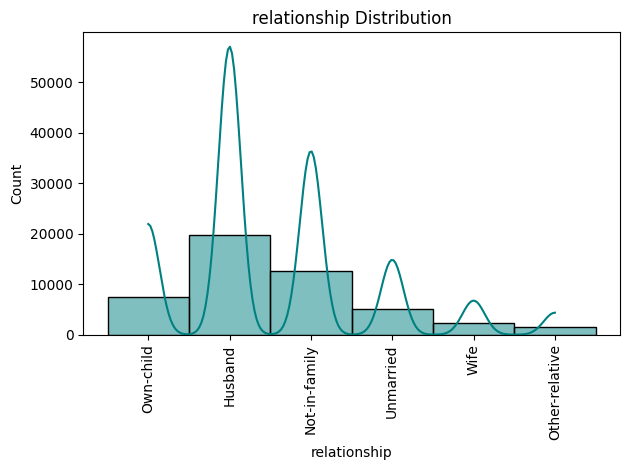

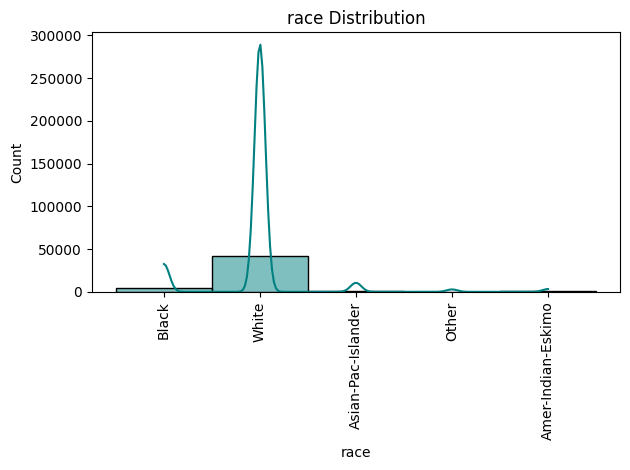

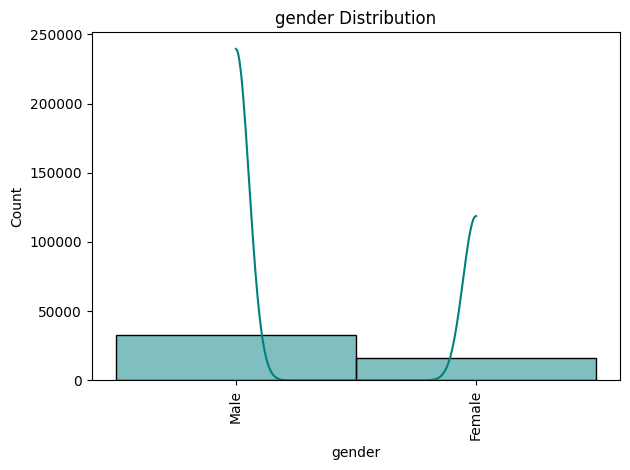

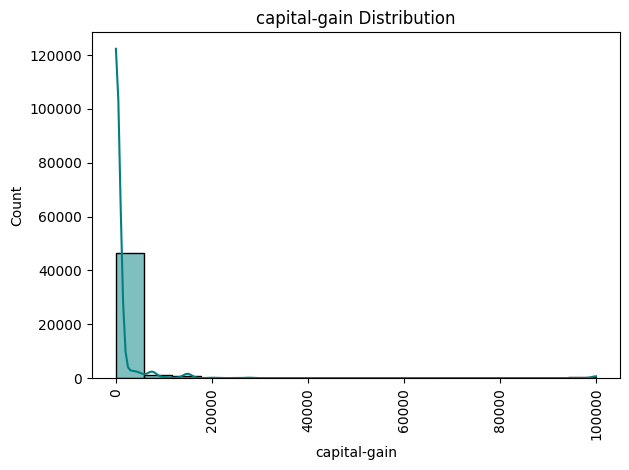

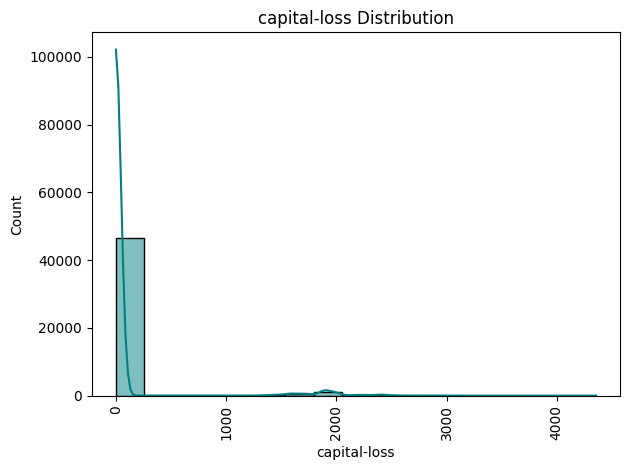

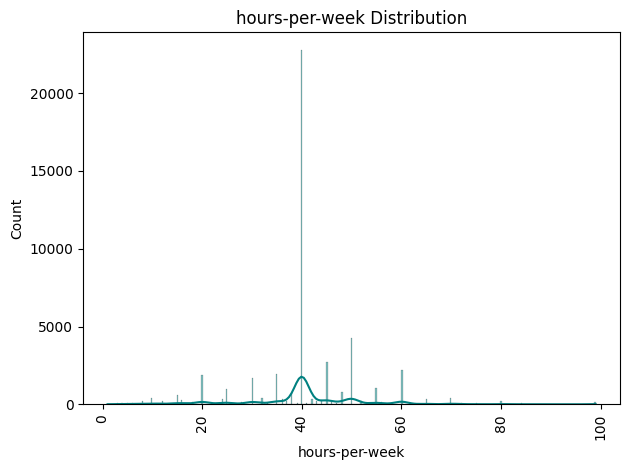

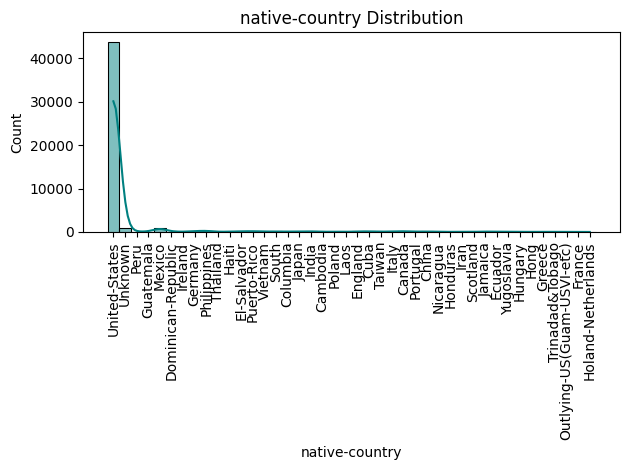

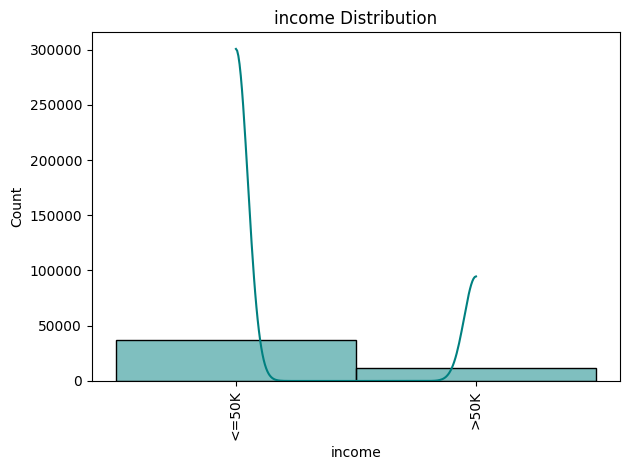

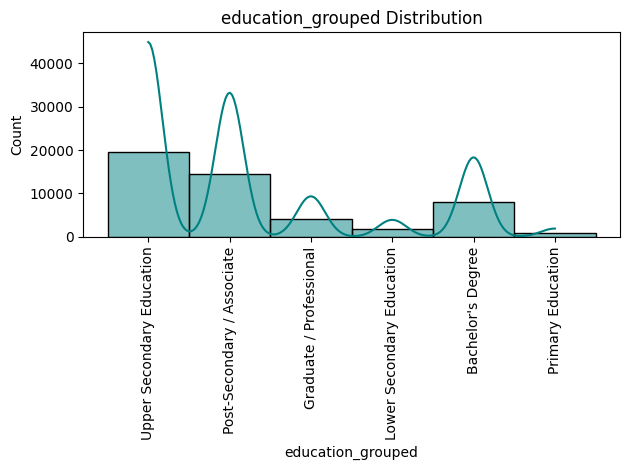

In [ ]:
for i in df.columns:
    sns.histplot(data=df, x=i, kde=True, color="teal")
    plt.title(f"{i} Distribution")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

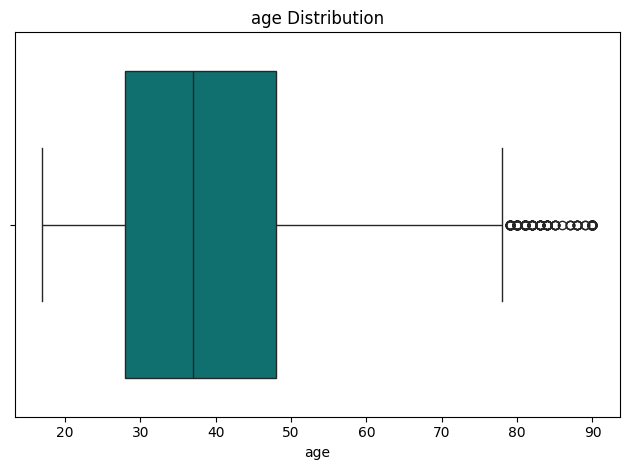

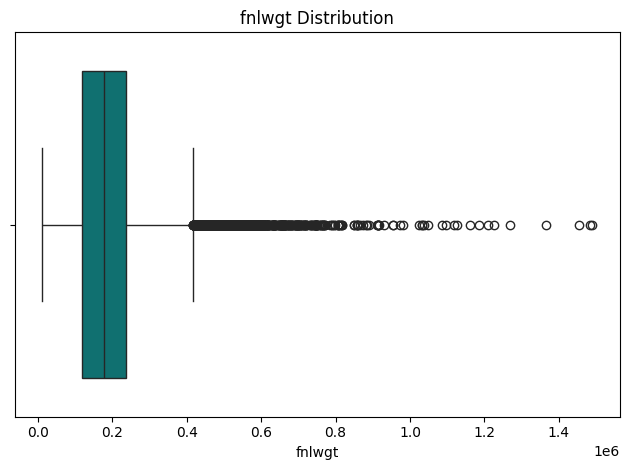

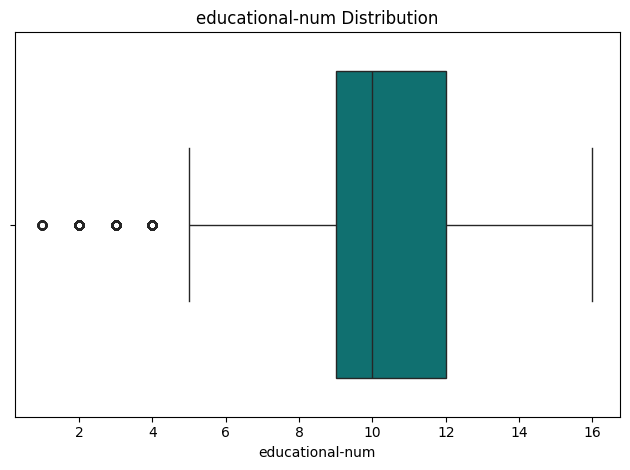

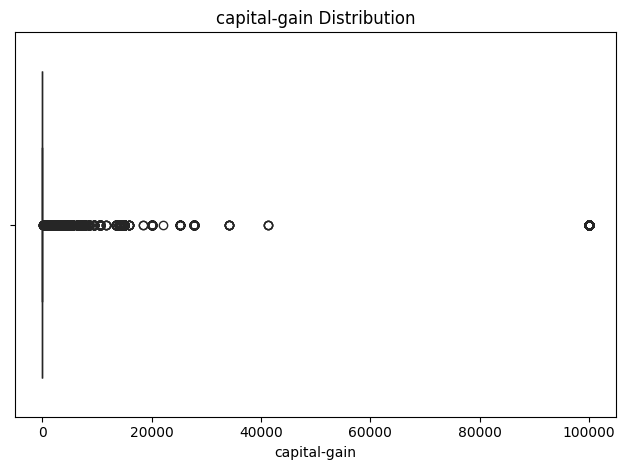

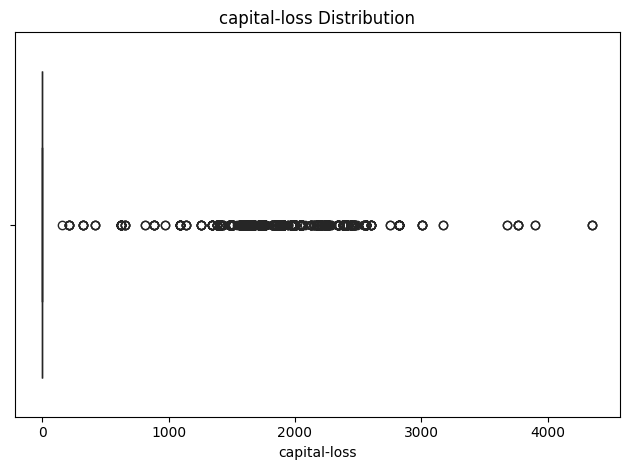

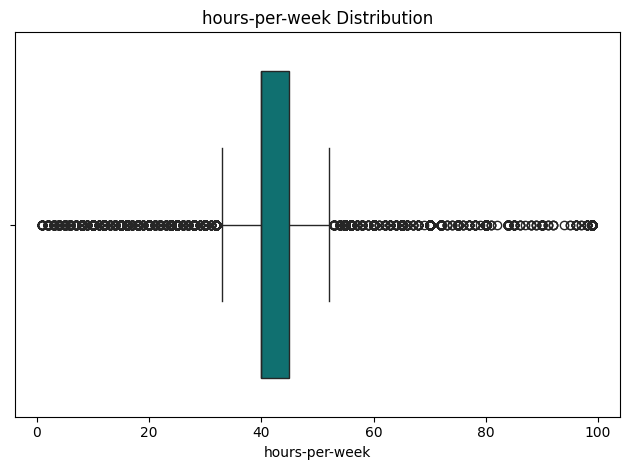

In [ ]:
for i in df.select_dtypes(exclude="O").columns:
    sns.boxplot(data=df, x=i, color="teal")
    plt.title(f"{i} Distribution")
    plt.tight_layout()
    plt.show()

# Preprocessing

## Encoding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                48790 non-null  int64 
 1   workclass          48790 non-null  object
 2   fnlwgt             48790 non-null  int64 
 3   education          48790 non-null  object
 4   educational-num    48790 non-null  int64 
 5   marital-status     48790 non-null  object
 6   occupation         48790 non-null  object
 7   relationship       48790 non-null  object
 8   race               48790 non-null  object
 9   gender             48790 non-null  object
 10  capital-gain       48790 non-null  int64 
 11  capital-loss       48790 non-null  int64 
 12  hours-per-week     48790 non-null  int64 
 13  native-country     48790 non-null  object
 14  income             48790 non-null  object
 15  education_grouped  48790 non-null  object
dtypes: int64(6), object(10)
memory usage: 6.3+ MB

In [ ]:
lis = ["workclass", "marital-status", "occupation", "relationship", "race", "native-country"]

encoder = LabelEncoder()
for i in lis:
    name = f"{i}" + "_En"
    df[name] = encoder.fit_transform(df[i])



In [ ]:
df = df.drop(columns= lis, axis=1)

In [ ]:
encoded = pd.get_dummies(df["gender"], drop_first=True, prefix="gender", dtype= int)
df = pd.concat([df, encoded], axis=1)

df.drop("gender", axis=1, inplace=True)

In [ ]:
income_E = {">50K": 1, "<=50K": 0}
df["income"] = df["income"].map(income_E)

## Drop Un-necessary columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                48790 non-null  int64 
 1   fnlwgt             48790 non-null  int64 
 2   education          48790 non-null  object
 3   educational-num    48790 non-null  int64 
 4   capital-gain       48790 non-null  int64 
 5   capital-loss       48790 non-null  int64 
 6   hours-per-week     48790 non-null  int64 
 7   income             48790 non-null  int64 
 8   education_grouped  48790 non-null  object
 9   workclass_En       48790 non-null  int64 
 10  marital-status_En  48790 non-null  int64 
 11  occupation_En      48790 non-null  int64 
 12  relationship_En    48790 non-null  int64 
 13  race_En            48790 non-null  int64 
 14  native-country_En  48790 non-null  int64 
 15  gender_Male        48790 non-null  int64 
dtypes: int64(14), object(2)
memory usage: 6.3+ MB

In [ ]:
df = df.drop(columns= ["education", "fnlwgt", "education_grouped"], axis=1)

<Axes: >

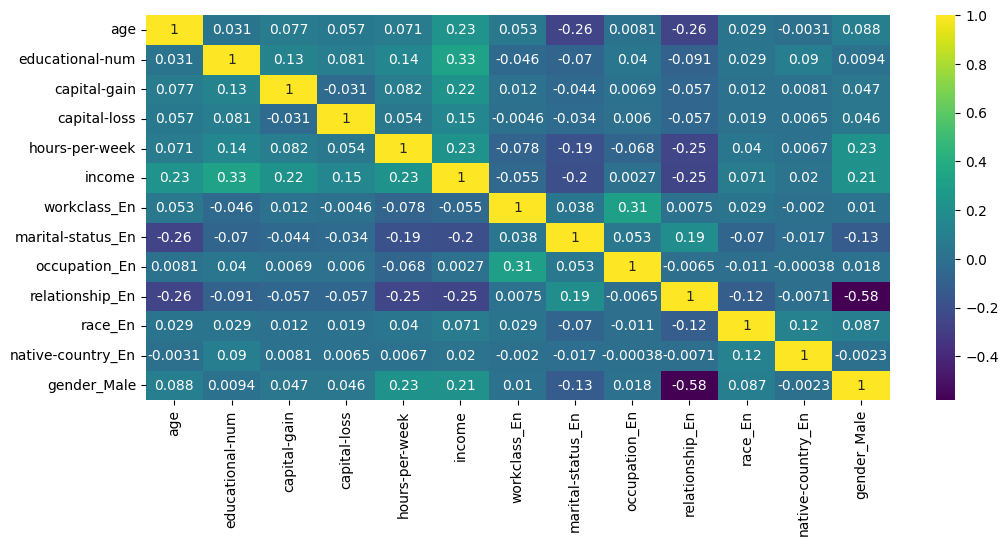

In [ ]:
plt.figure(figsize=(12,5))
sns.heatmap(df.corr(), annot=True, cmap="viridis")

## Splitting

In [ ]:
x = df.drop(columns= ["income"], axis=1)
y = df[["income"]]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True )

## Scaling

In [ ]:
scaler = StandardScaler()


In [ ]:
# fit on the training set
x_train_scaled = scaler.fit_transform(x_train)

# apply the transformations to the test set
x_test_scaled = scaler.transform(x_test)

In [ ]:
scaler.fit(x_train)


# Modeling

### SVM Model

In [ ]:
svm_model = SVC()
svm_model.fit(x_train_scaled, y_train)

SVC()

In [ ]:
y_pred_svm = svm_model.predict(x_test_scaled)

In [ ]:
print(accuracy_score(y_test, y_pred_svm))

0.8558106169296987


In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      7474
           1       0.77      0.55      0.64      2284

    accuracy                           0.86      9758
   macro avg       0.82      0.75      0.78      9758
weighted avg       0.85      0.86      0.85      9758



<Axes: >

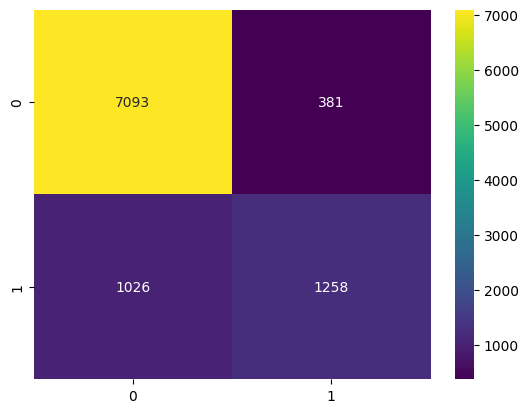

In [ ]:
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(conf_matrix_svm, annot=True, cmap="viridis", fmt='g')

### KNN

In [ ]:
knn_model = KNeighborsClassifier()
knn_model.fit(x_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn_model.predict(x_test_scaled)

In [ ]:
print(accuracy_score(y_test, y_pred_knn))

0.834392293502767


In [ ]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      7474
           1       0.66      0.59      0.63      2284

    accuracy                           0.83      9758
   macro avg       0.77      0.75      0.76      9758
weighted avg       0.83      0.83      0.83      9758



<Axes: >

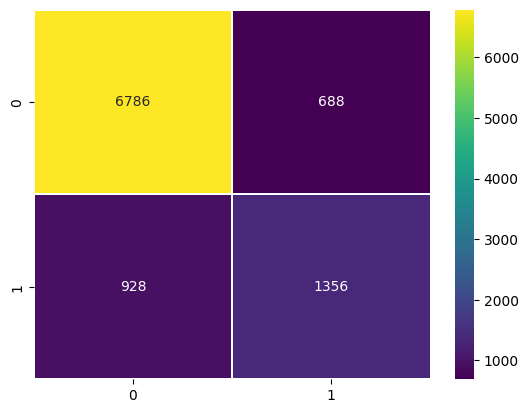

In [ ]:
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(conf_matrix_knn, annot=True, cmap="viridis", fmt="g", linewidths= 0.1)

## Using RandomsearchCV

### SVM Model

In [ ]:
selected_model = SVC()


params = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": [0.001, 0.01, 0.1, 1, 10]
}

random_search = RandomizedSearchCV(
    estimator=selected_model,
    param_distributions=params,
    n_iter=3,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train_scaled, y_train)

print("Best parameters: ", random_search.best_params_)

Best parameters:  {'kernel': 'rbf', 'gamma': 0.1, 'C': 1}


In [ ]:
svm_model_RS = random_search.best_estimator_

In [ ]:
y_pred_svm_RS = svm_model_RS.predict(x_test_scaled)

In [ ]:
print(accuracy_score(y_test, y_pred_svm_RS))

0.8554006968641115


In [ ]:
print(classification_report(y_test, y_pred_svm_RS))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      7474
           1       0.77      0.55      0.64      2284

    accuracy                           0.86      9758
   macro avg       0.82      0.75      0.77      9758
weighted avg       0.85      0.86      0.85      9758



<Axes: >

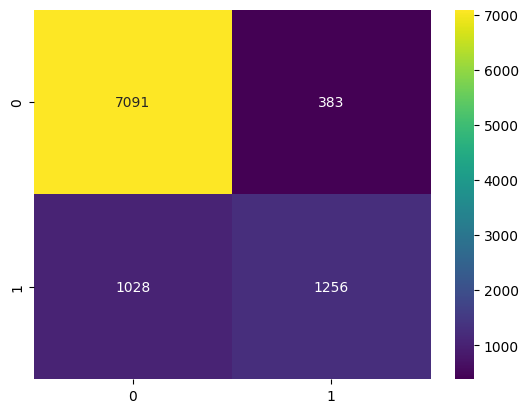

In [ ]:
conf_matrix_svm_GS = confusion_matrix(y_test, y_pred_svm_RS)
sns.heatmap(conf_matrix_svm_GS, annot=True, cmap="viridis", fmt='g')

### KNN Model

In [ ]:
selected_model = KNeighborsClassifier()


params = {
    'n_neighbors': [3,5,7,9,11]
}

random_search = RandomizedSearchCV(
    estimator=selected_model,
    param_distributions=params,
    n_iter=3,
    cv=5,
    scoring="accuracy",
    random_state=42
)

random_search.fit(x_train_scaled, y_train)

print("Best parameters: ", random_search.best_params_)

Best parameters:  {'n_neighbors': 11}


In [ ]:
knn_model_RS = random_search.best_estimator_

In [ ]:
y_pred_knn_RS = knn_model_RS.predict(x_test_scaled)

In [ ]:
print(accuracy_score(y_test, y_pred_knn_RS))

0.8422832547653207


In [ ]:
print(classification_report(y_test, y_pred_knn_RS))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      7474
           1       0.69      0.59      0.64      2284

    accuracy                           0.84      9758
   macro avg       0.79      0.75      0.77      9758
weighted avg       0.84      0.84      0.84      9758



<Axes: >

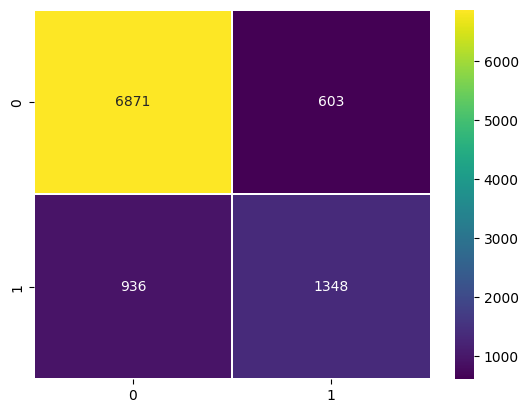

In [ ]:
conf_matrix_knn_GS = confusion_matrix(y_test, y_pred_knn_RS)
sns.heatmap(conf_matrix_knn_GS, annot=True, cmap="viridis", fmt="g", linewidths= 0.1)